In [228]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy.stats import chi2_contingency, f_oneway, jarque_bera, probplot
import plotly.express as px
from pathlib import Path

# Load the data

In [229]:
# pathlib is a module in Python that provides an object-oriented interface 
# for working with file system paths.
current = Path.cwd()
parent = current.parent
# load the data 

df_final = pd.read_csv(parent /'data/cleaned_swiggy.csv')
# Display the first few rows of the DataFrame
display(df_final.head())

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,time_taken,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,...,24,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,stormy,jam,...,33,BANG,25,3,friday,0,5.0,19.0,evening,20.183530
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,sandstorms,low,...,26,BANG,19,3,saturday,1,15.0,8.0,morning,1.552758
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,sunny,medium,...,21,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,cloudy,high,...,30,CHEN,26,3,saturday,1,15.0,13.0,afternoon,6.210138


In [230]:
df_final.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutes',
       'order_time_hour', 'order_time_of_day', 'distance'],
      dtype='object')

# Preliminary Analysis

In [231]:
df_final.isnull().sum()

rider_id                   0
age                     1854
ratings                 1908
restaurant_latitude     3630
restaurant_longitude    3630
delivery_latitude       3630
delivery_longitude      3630
order_date                 0
weather                  525
traffic                  510
vehicle_condition          0
type_of_order              0
type_of_vehicle            0
multiple_deliveries      993
festival                 228
city_type               1198
time_taken                 0
city_name                  0
order_day                  0
order_month                0
order_day_of_week          0
is_weekend                 0
pickup_time_minutes     1640
order_time_hour         1640
order_time_of_day          0
distance                3630
dtype: int64

In [232]:
# number of rows  in the data that have missing values

missing_rows = (
    df_final
    .isnull()
    .any(axis=1)
    .sum()
    )

print(f"Number of rows with missing values: {missing_rows}")
# Display the percentage of missing values 
print(f"Percentage of missing values: {missing_rows / len(df_final) * 100:.2f}%")

Number of rows with missing values: 7438
Percentage of missing values: 16.35%


In [233]:
# check if there are any duplicate rows in the DataFrame
df_final.duplicated().sum()

np.int64(0)

**There are no duplicate rows in the data and none were created by our data cleaning step**

In [234]:
# data types
df_final.dtypes

rider_id                 object
age                     float64
ratings                 float64
restaurant_latitude     float64
restaurant_longitude    float64
delivery_latitude       float64
delivery_longitude      float64
order_date               object
weather                  object
traffic                  object
vehicle_condition         int64
type_of_order            object
type_of_vehicle          object
multiple_deliveries     float64
festival                 object
city_type                object
time_taken                int64
city_name                object
order_day                 int64
order_month               int64
order_day_of_week        object
is_weekend                int64
pickup_time_minutes     float64
order_time_hour         float64
order_time_of_day        object
distance                float64
dtype: object

In [235]:
# numeric columns
num_cols = df_final.columns[[1,2,3,4,5,6,16,22,25]].tolist()
# categorical columns
cat_cols = [col for col in df_final.columns if col not in num_cols]

print(f"there are {len(num_cols)} numeric columns and {len(cat_cols)} categorical columns in the dataset")
print("*"*50)
# Display the numeric columns
print("Numeric columns:", num_cols)
# Display the categorical columns
print("*"*50)
print("Categorical columns:", cat_cols)
print("*"*50)

there are 9 numeric columns and 17 categorical columns in the dataset
**************************************************
Numeric columns: ['age', 'ratings', 'restaurant_latitude', 'restaurant_longitude', 'delivery_latitude', 'delivery_longitude', 'time_taken', 'pickup_time_minutes', 'distance']
**************************************************
Categorical columns: ['rider_id', 'order_date', 'weather', 'traffic', 'vehicle_condition', 'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival', 'city_type', 'city_name', 'order_day', 'order_month', 'order_day_of_week', 'is_weekend', 'order_time_hour', 'order_time_of_day']
**************************************************


In [236]:
# statistical summary of the numeric columns
df_final[num_cols].describe()

,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,time_taken,pickup_time_minutes,distance
count,43648.000000,43594.000000,41872.000000,41872.000000,41872.000000,41872.000000,45502.000000,43862.000000,41872.000000
mean,29.555008,4.635287,18.913696,76.921664,18.977356,76.985325,26.297591,9.989399,9.719296
std,5.761482,0.313827,5.467265,3.503107,5.469056,3.503260,9.386419,4.087516,5.602890
min,20.000000,2.500000,9.957144,72.768726,9.967144,72.778726,10.000000,5.000000,1.465067
25%,25.000000,4.500000,12.986047,73.897902,13.065996,73.940327,19.000000,5.000000,4.657655
50%,30.000000,4.700000,19.065838,76.618203,19.124049,76.662620,26.000000,10.000000,9.193014
75%,35.000000,4.900000,22.751234,78.368855,22.820040,78.405467,32.000000,15.000000,13.680920
max,39.000000,5.000000,30.914057,88.433452,31.054057,88.563452,54.000000,15.000000,20.969489


In [237]:
# statistical summary of the categorical columns
df_final.describe(include="object").T

,count,unique,top,freq
rider_id,45502,1320,PUNERES01DEL01,67
order_date,45502,44,2022-03-15,1190
weather,44977,6,fog,7654
traffic,44992,4,low,15477
type_of_order,45502,4,snack,11512
type_of_vehicle,45502,4,motorcycle,26427
festival,45274,2,no,44380
city_type,44304,3,metropolitian,34029
city_name,45502,22,JAP,3439
order_day_of_week,45502,7,wednesday,7077


## Missing Value Analysis

In [238]:
import missingno as msno

### Matrix Plot

<Axes: >

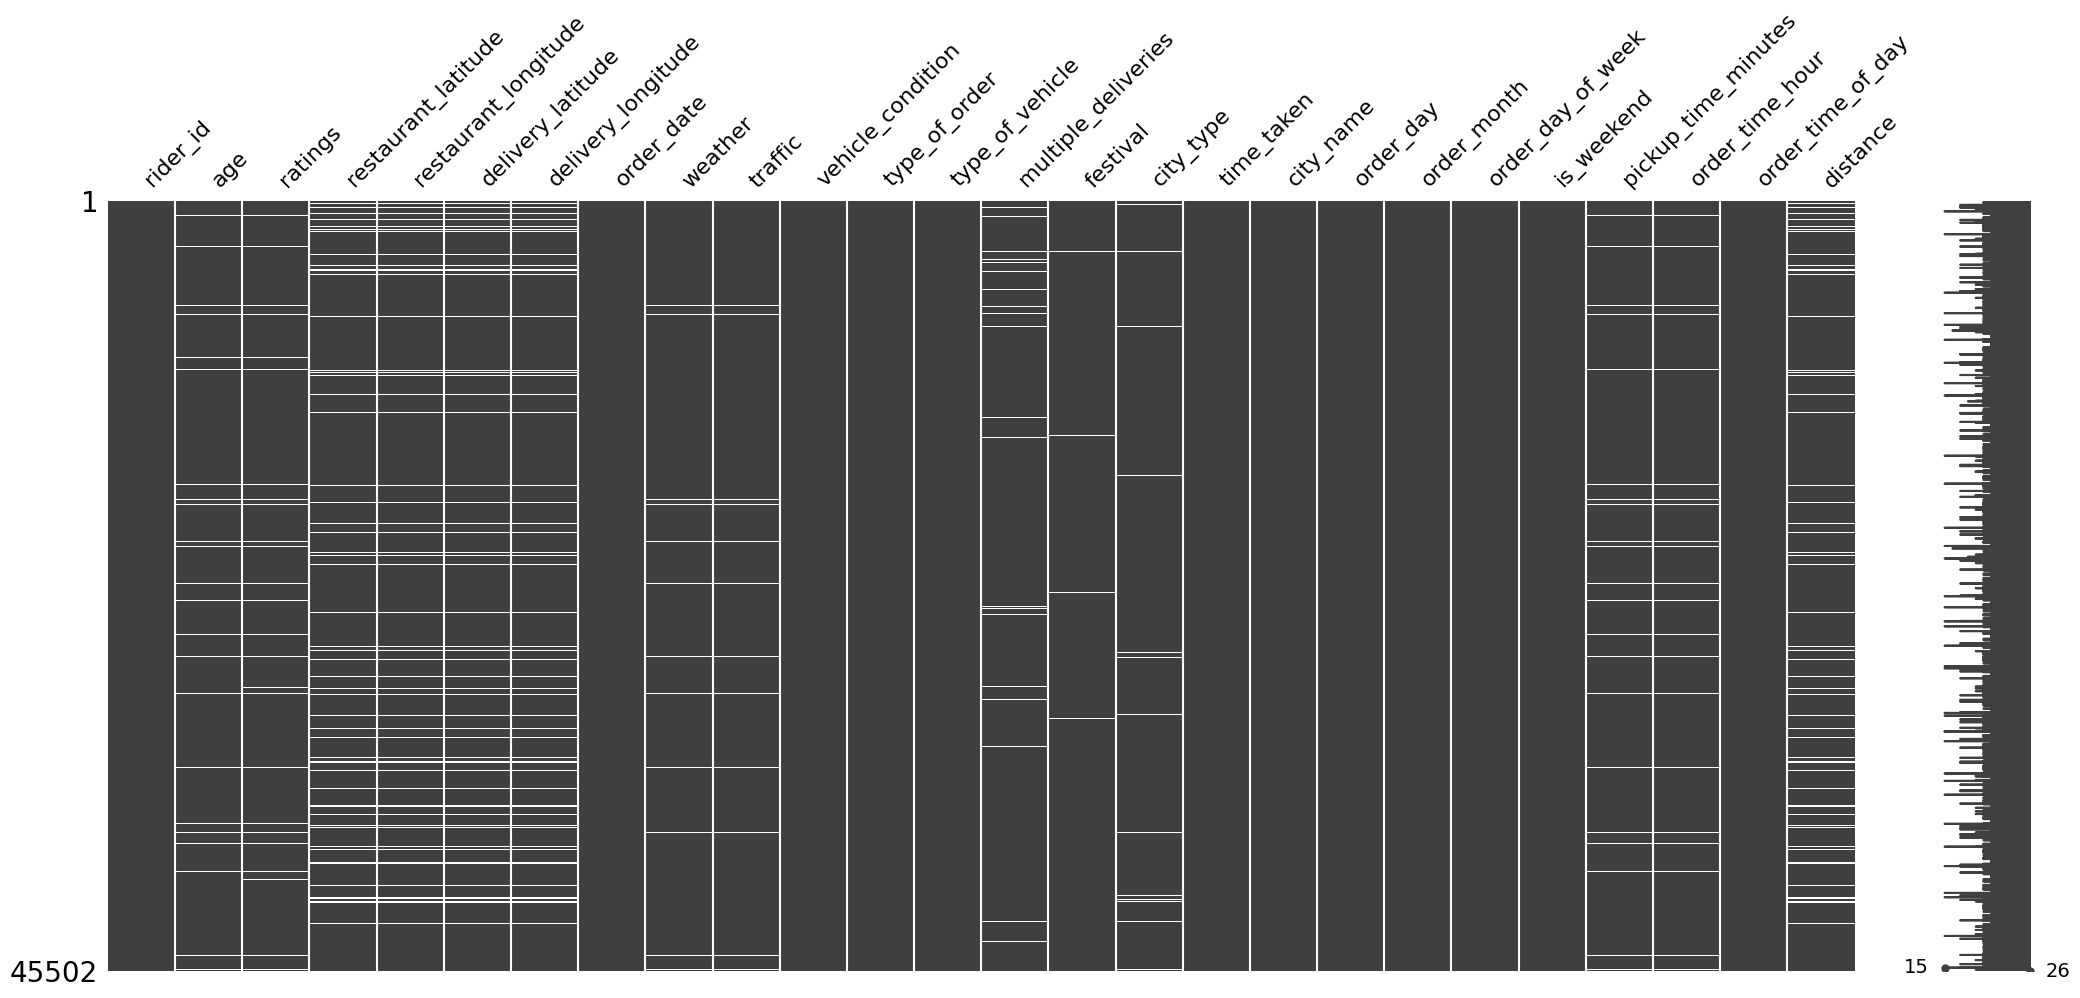

In [239]:
msno.matrix(df_final)

### Corr

<Axes: >

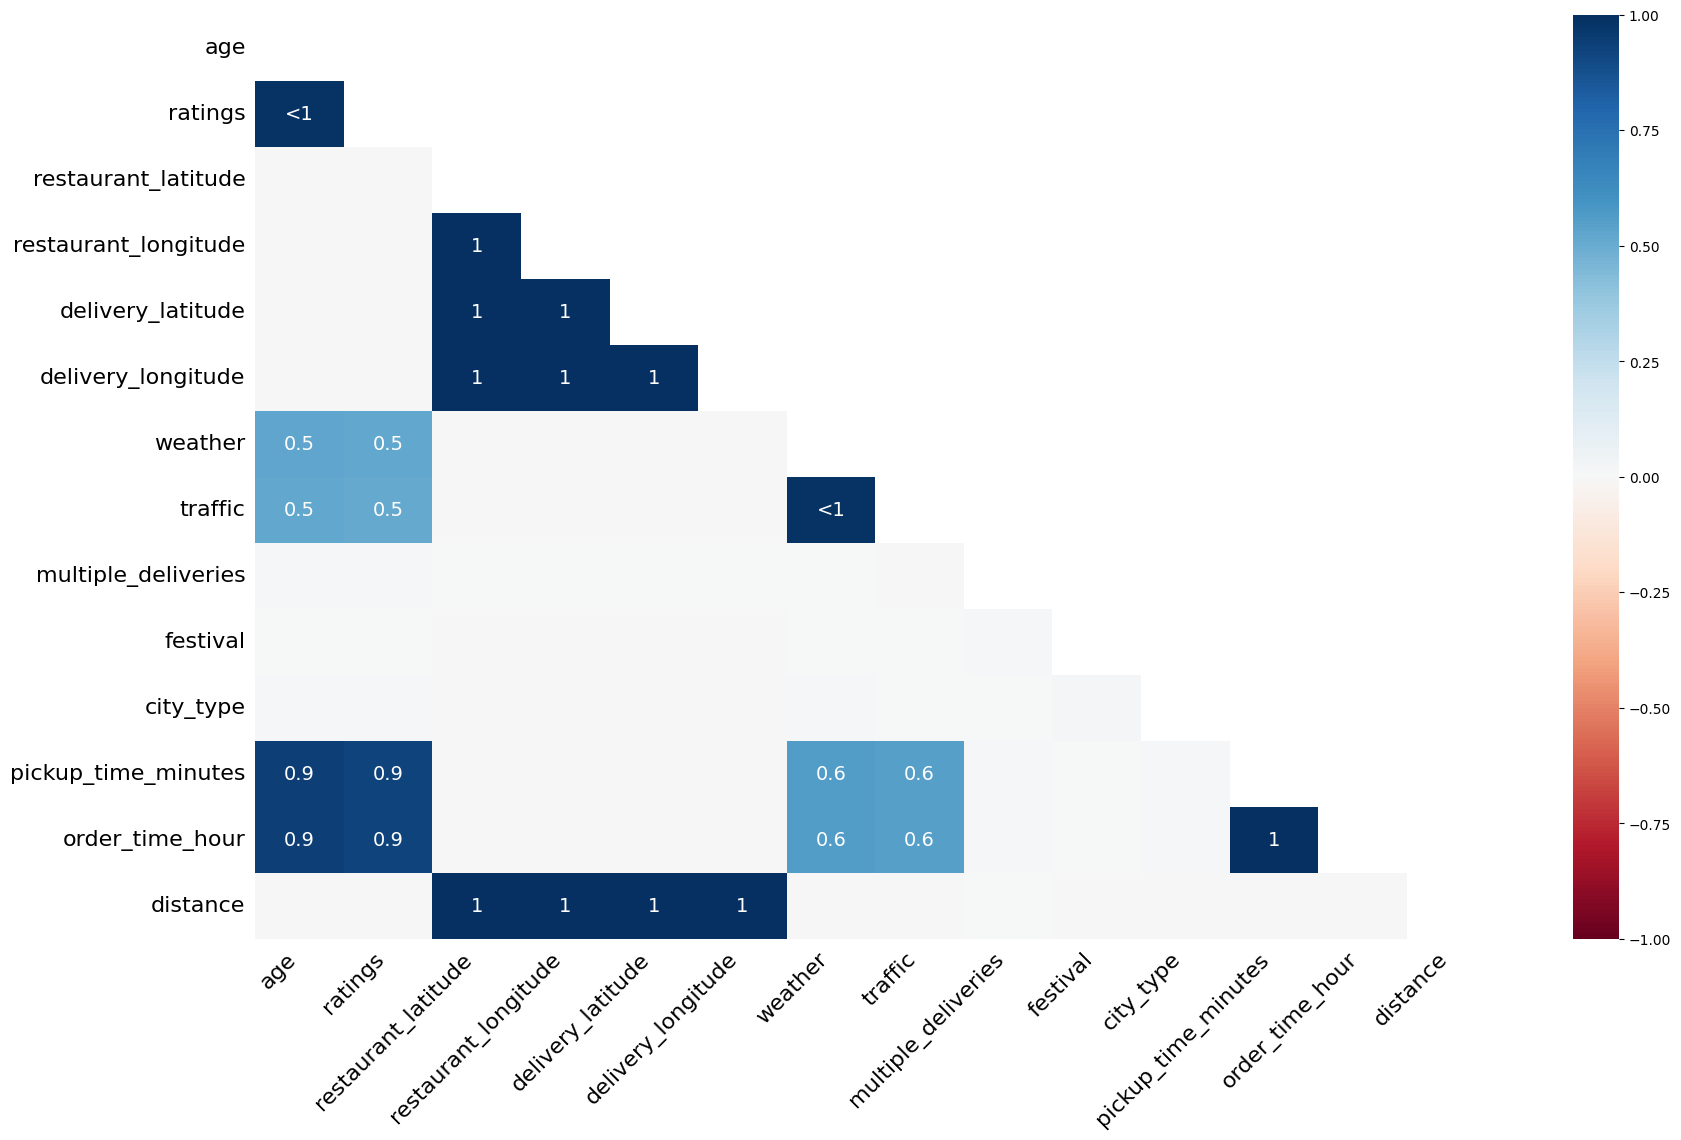

In [240]:
msno.heatmap(df_final)

### Dendrogram

<Axes: >

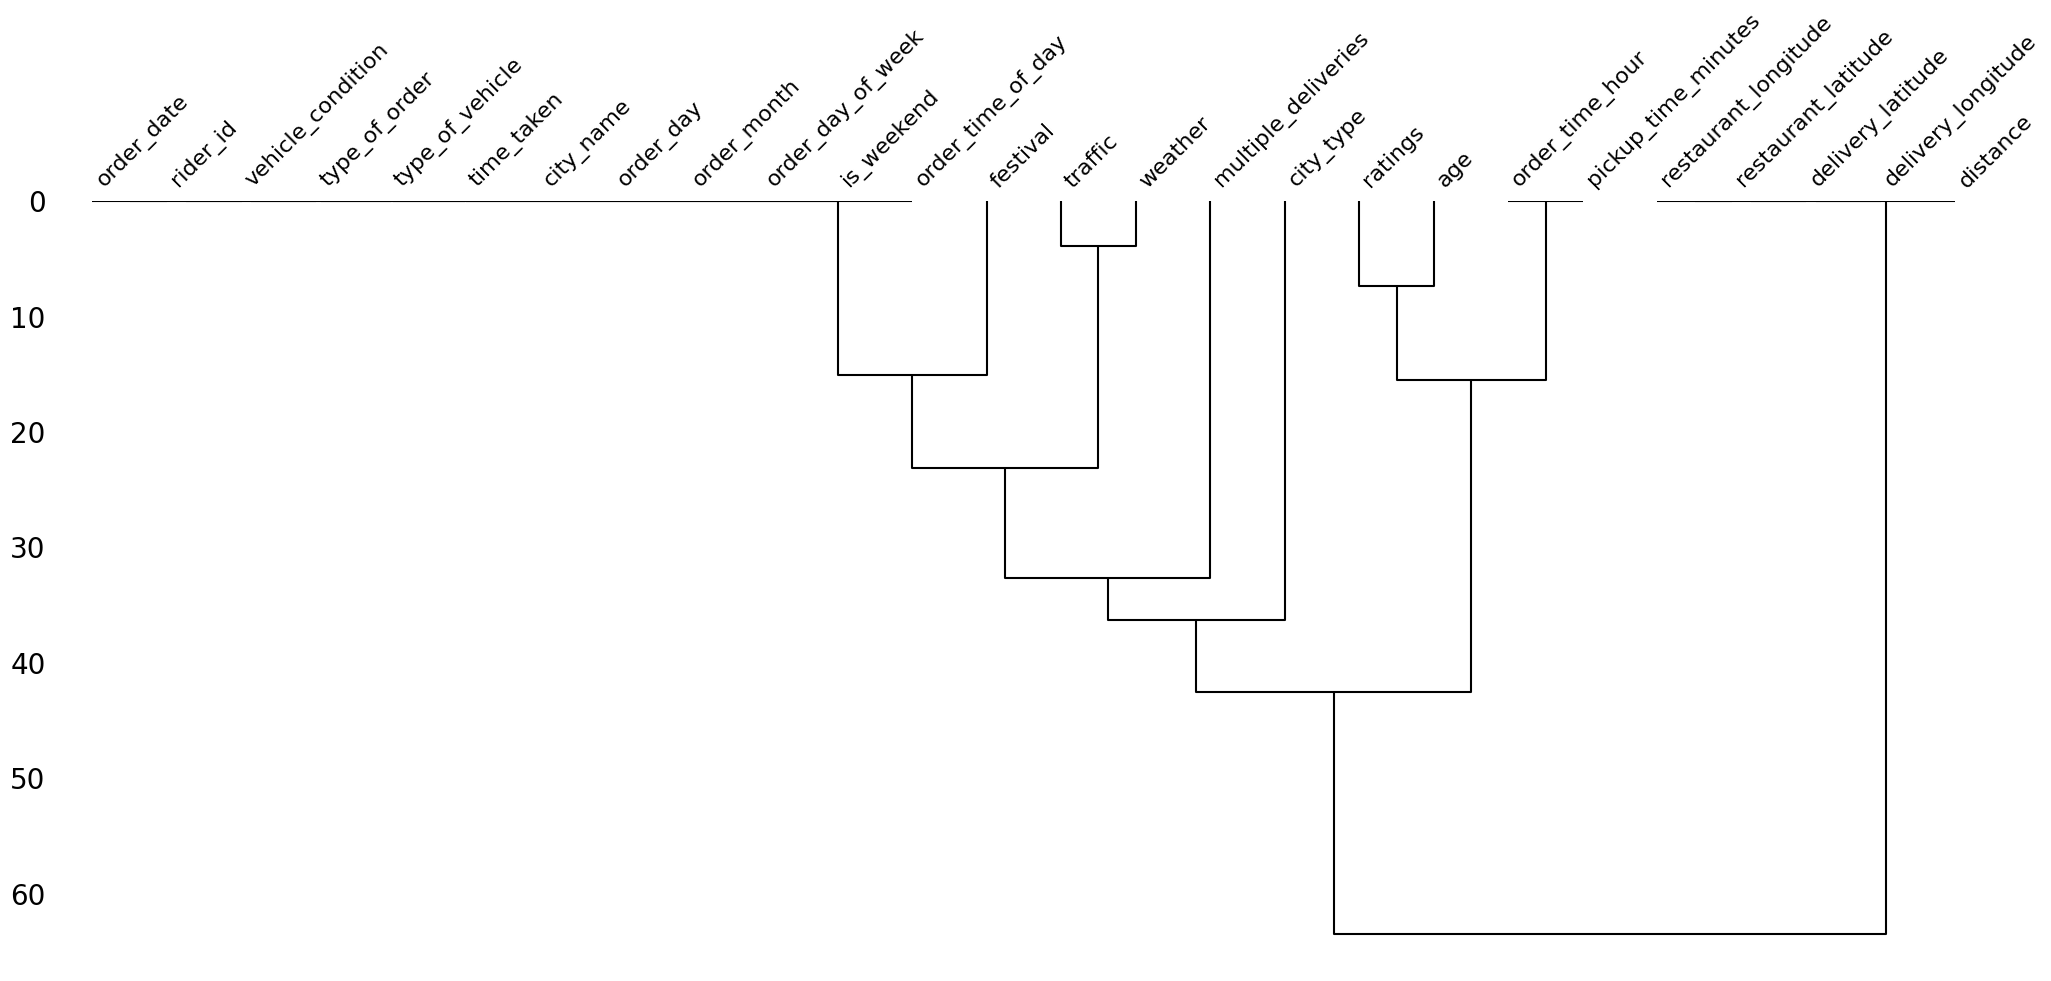

In [241]:
msno.dendrogram(df_final)

# Functions to perform analysis

In [297]:
def numerical_analysis(df, column_name,cat_col=None,bins="auto"):
    # create the figure
    fig = plt.figure(figsize=(15, 8))
    # create the grid
    gs = GridSpec(nrows= 2, ncols=2, figure=fig)
    # create the first subplot
    ax1 = fig.add_subplot(gs[0, 0]) 
    # create the second subplot
    ax2 = fig.add_subplot(gs[0, 1])
    # create the third subplot
    ax3 = fig.add_subplot(gs[1, :])
    # plot the kde plot
    sns.kdeplot(df[column_name], ax=ax1,hue=cat_col)
    # plot the box plot
    sns.boxplot(x=df[column_name], ax=ax2, hue=cat_col)
    # plot the histogram
    sns.histplot(df[column_name], ax=ax3, bins=bins, kde=True)
    plt.tight_layout()
    plt.show()

def numerical_categorical_analysis(df, cat_col, num_col):
    fig, ax = plt.subplots(2, 2, figsize=(15, 7.5))
    # plot the barplot
    sns.barplot(x=cat_col, y=num_col, data=df, ax=ax[0, 0])
    # plot the boxplot
    sns.boxplot(x=cat_col, y=num_col, data=df, ax=ax[0, 1])
    # plot the violin plot
    sns.violinplot(x=cat_col, y=num_col, data=df, ax=ax[1, 0])
    # plot the strip plot
    sns.stripplot(x=cat_col, y=num_col, data=df,dodge=True, ax=ax[1, 1])
    plt.tight_layout()
    plt.show()

def categorical_analysis(df, column_name):
    # print the value counts of categories
    counts = df[column_name].value_counts()
    percentages = df[column_name].value_counts(normalize=True) * 100

    display(
        pd.DataFrame({
            "Count": counts,
            "Percentage": percentages.round(2).astype(str) + '%'
        })
    )

    print("*" * 50)
    unique_values = df[column_name].nunique()
    print(f"Number of unique values in {column_name}: {unique_values}")
    print("*" * 50)
    unique_values_list = df[column_name].unique()
    print(f"Unique values in {column_name}: {unique_values_list}")
    print("*" * 50)

    # create the figure
    sns.countplot(x=column_name, data=df)
    plt.xticks(rotation=45)
    plt.title(f"Count Plot for {column_name}")
    plt.show()


def multivariate_analysis(df, num_col, cat_col_1, cat_col_2):
    fig, ax = plt.subplots(2, 2, figsize=(15, 7.5))
    # plot the barplot
    sns.barplot(x=cat_col_1, y=num_col, hue=cat_col_2, data=df, ax=ax[0, 0])
    # plot the boxplot
    sns.boxplot(x=cat_col_1, y=num_col, hue=cat_col_2, data=df, ax=ax[0, 1])
    # plot the violin plot
    sns.violinplot(x=cat_col_1, y=num_col, hue=cat_col_2, data=df, ax=ax[1, 0])
    # plot the strip plot
    sns.stripplot(x=cat_col_1, y=num_col, hue=cat_col_2,dodge=True, data=df, ax=ax[1, 1])
    plt.tight_layout()
    plt.show()

def chi2_test(df,col1,col2,alpha=0.05):

    data = (
        df.loc[:, [col1, col2]]
        .dropna()
    )
    # Create a contingency table
    contingency_table = pd.crosstab(data[col1], data[col2])
    # Perform the Chi-Squared test
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    # Print the results
    print(f"Chi-Squared test results for {col1} and {col2}:")
    print(f"Chi2 statistic: {chi2:.4f}")
    print(f"Degrees of freedom: {dof}")
    print(f"Expected frequencies:\n{expected}")
    print(f"p-value: {p:.4f}")
    # Check if the null hypothesis can be rejected
    if p <= alpha:
        print(f"Reject the null hypothesis at alpha = {alpha}")
    else:
        print(f"Fail to reject the null hypothesis at alpha = {alpha}")

def anova_test(df, cat_col, num_col,alpha=0.05):

    data = (
        df.loc[:, [cat_col, num_col]]
        .dropna()
    )
    cat_group = data.groupby(cat_col)
    groups = [group[num_col].values for name, group in cat_group]
    f_statistic, p_value = f_oneway(*groups)
    print(f"ANOVA test results for {cat_col} and {num_col}:")
    print(f"F-statistic: {f_statistic:.4f}")
    print(f"p-value: {p_value:.4f}")
    # Check if the null hypothesis can be rejected
    if p_value <= alpha:
        print(f"Reject the null hypothesis at alpha = {alpha}")
    else:
        print(f"Fail to reject the null hypothesis at alpha = {alpha}")

def test_for_normality(df, col_name, alpha=0.05):
    # Perform the Jarque-Bera test
    jb_statistic, p_value = jarque_bera(df[col_name])
    print(f"Jarque-Bera test results for {col_name}:")
    print(f"JB statistic: {jb_statistic:.4f}")
    print(f"p-value: {p_value:.4f}")
    # Check if the null hypothesis can be rejected
    if p_value <= alpha:
        print(f"Reject the null hypothesis at alpha = 0.05. The data is not normally distributed.")
    else:
        print(f"Fail to reject the null hypothesis at alpha = 0.05")  


# Column Wise Analysis

In [243]:
df_final.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutes',
       'order_time_hour', 'order_time_of_day', 'distance'],
      dtype='object')

## Time Taken (Target)

In [244]:
# data type of column

df_final["time_taken"].dtype

dtype('int64')

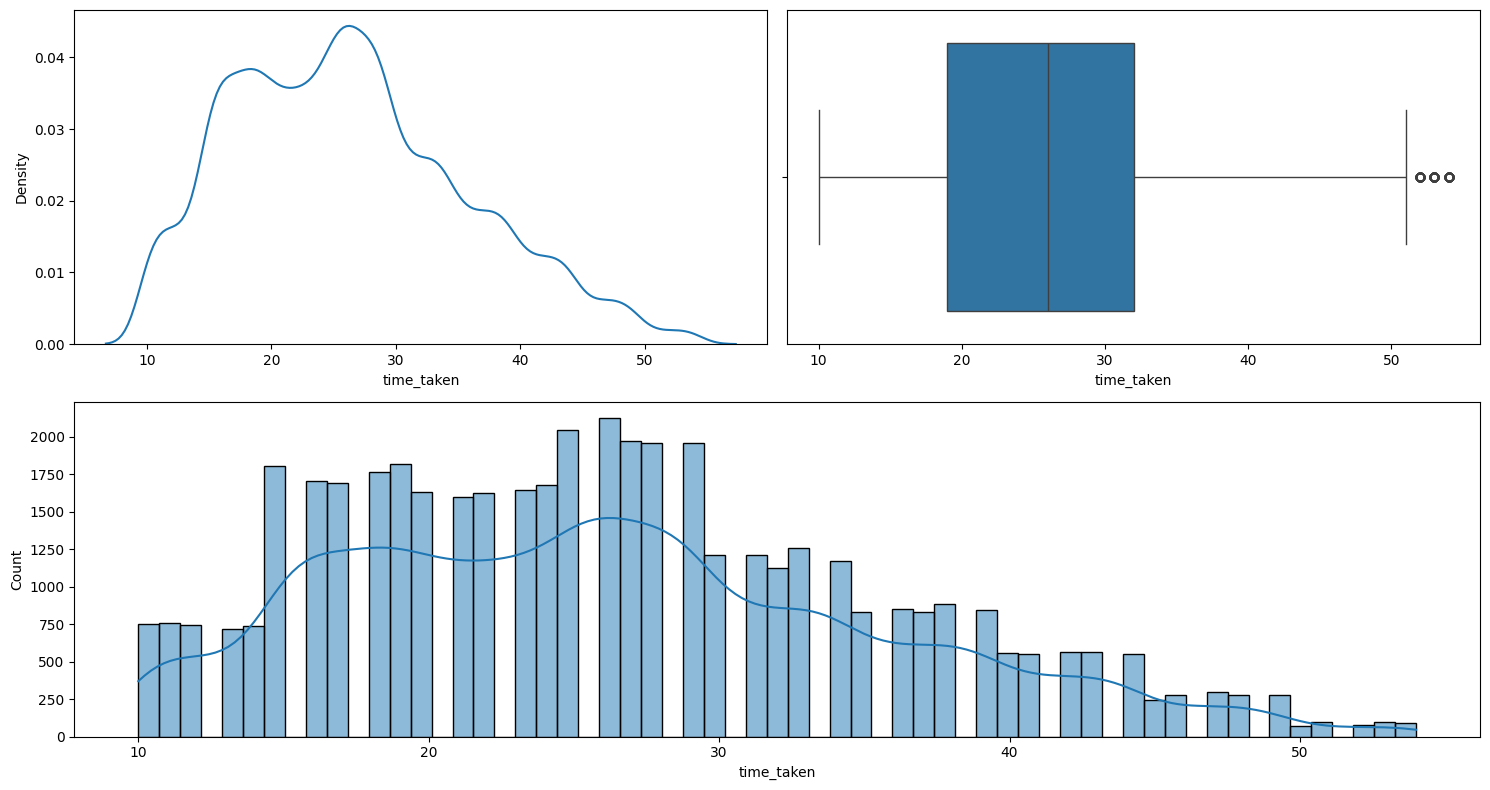

In [245]:
# numerical analysis of the column
numerical_analysis(df_final, "time_taken")

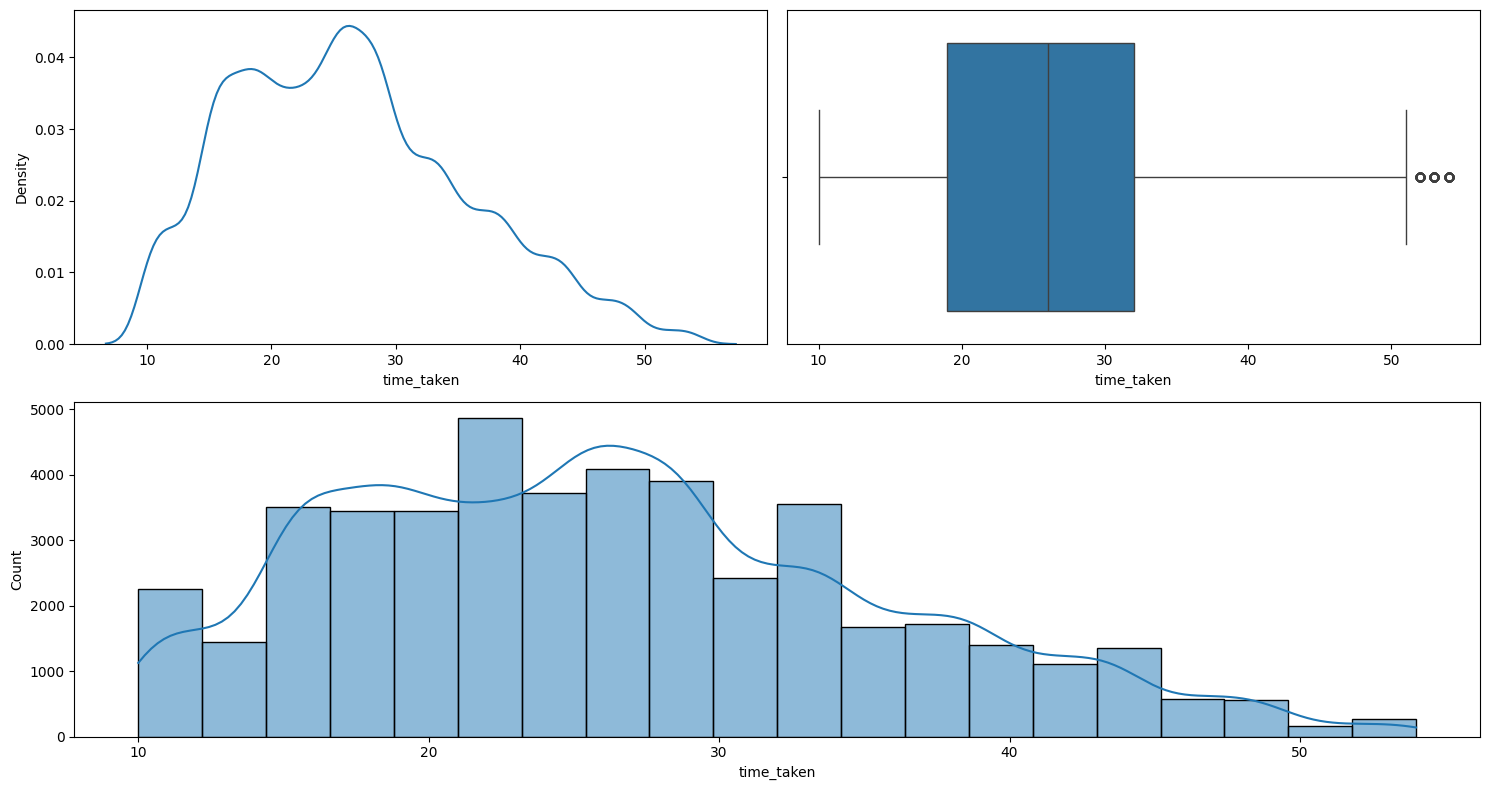

In [246]:
numerical_analysis(df_final, "time_taken",bins=20)

### 🔍 Observations on `time_taken`:

1. **Bimodal distribution** – does **not** follow normality.  
2. `time_taken` is **continuous** and **discrete-like** (appears in rounded steps).  
3. **Right-skewed** with a **long tail**.  
4. **Few outliers** above **50 mins**.  
5. **Most values** fall between **15–40 mins**.

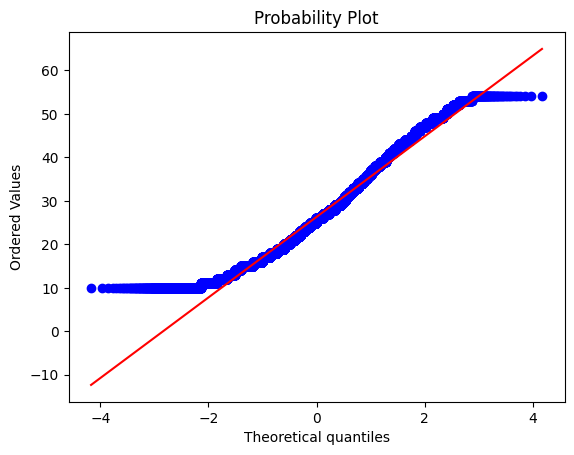

In [247]:
# plot QQ plot for the target 
probplot(df_final["time_taken"], dist="norm", plot=plt)
plt.show()

In [248]:
# test for normality

test_for_normality(df_final, "time_taken", alpha=0.05)

Jarque-Bera test results for time_taken:
JB statistic: 1972.2806
p-value: 0.0000
Reject the null hypothesis at alpha = 0.05. The data is not normally distributed.


In [249]:
# check out the rows where data is acting as outlier 

target_25_per , target_75_per = df_final["time_taken"].quantile([0.25, 0.75])
iqr = target_75_per - target_25_per
lower_bound = target_25_per - (1.5 * iqr)
upper_bound = target_75_per + (1.5 * iqr)

df_final.loc[(df_final['time_taken']>upper_bound),"traffic"].value_counts()

traffic
jam     241
high     24
Name: count, dtype: int64

In [250]:
df_final.loc[(df_final['time_taken']>upper_bound),"weather"].value_counts()

weather
fog           57
sunny         51
windy         44
cloudy        44
stormy        37
sandstorms    32
Name: count, dtype: int64

In [251]:
# average distance
avg_distance = df_final["distance"].mean()
print(f"Average distance: {avg_distance:.2f}")
# average time taken
avg_distance_extreme = df_final.loc[(df_final['time_taken']>upper_bound),"distance"].mean()
print(f"Average distance for extreme time taken: {avg_distance_extreme:.2f}")

Average distance: 9.72
Average distance for extreme time taken: 13.29


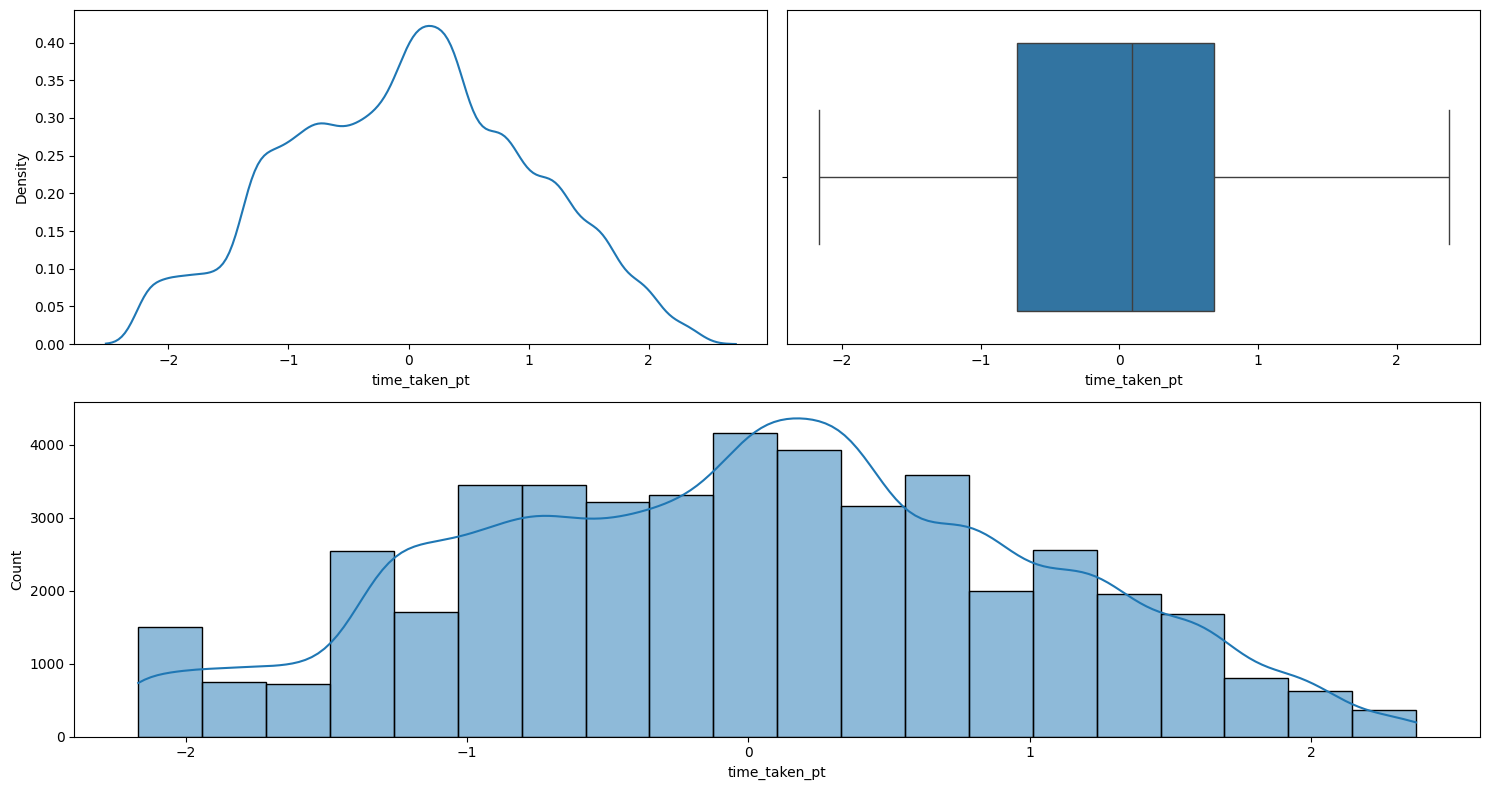

In [252]:
# fix traget column using transformation

from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method="yeo-johnson")
df_final["time_taken_pt"] = pt.fit_transform(df_final[["time_taken"]])

numerical_analysis(df_final, "time_taken_pt",bins=20)

### ✅ **Revised Observations after Yeo-Johnson Transformation**

1. **Distribution is now unimodal** and **closer to normal**, indicating the transformation was effective.  
2. **Skewness has reduced**, and the data appears more symmetric.  
3. **Outliers are minimized** or better integrated into the distribution.  
4. **Spread is more uniform**, enhancing model interpretability and performance.  
5. **Boxplot shows balanced IQR** with fewer extreme values.

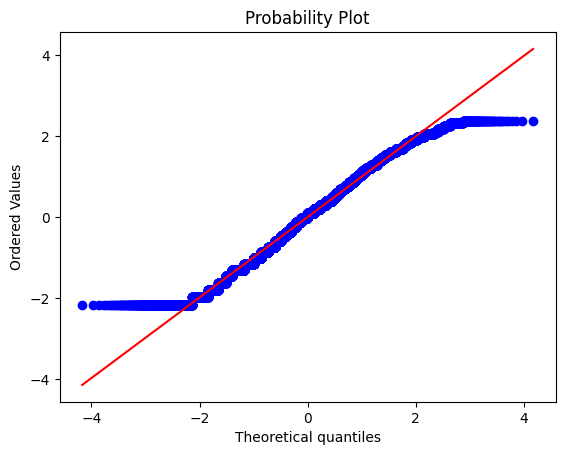

In [253]:
# plot QQ plot for the target after transformation

probplot(df_final['time_taken_pt'], plot=plt)
plt.show()

In [254]:
# test for normality

test_for_normality(df_final, "time_taken_pt")

Jarque-Bera test results for time_taken_pt:
JB statistic: 665.5167
p-value: 0.0000
Reject the null hypothesis at alpha = 0.05. The data is not normally distributed.


# Rider_ID

In [255]:
# datatype of rider id
df_final["rider_id"].dtype

dtype('O')

In [256]:
df_final[['rider_id','age','ratings']]

,rider_id,age,ratings
0,INDORES13DEL02,37.0,4.9
1,BANGRES18DEL02,34.0,4.5
2,BANGRES19DEL01,23.0,4.4
3,COIMBRES13DEL02,38.0,4.7
4,CHENRES12DEL01,32.0,4.6
...,...,...,...
45497,JAPRES04DEL01,30.0,4.8
45498,AGRRES16DEL01,21.0,4.6
45499,CHENRES08DEL03,30.0,4.9
45500,COIMBRES11DEL01,20.0,4.7


In [257]:
# sample of the data

rider_id_group = df_final[["rider_id", "age", "ratings"]].groupby("rider_id")
rider_id_group.head(5).sort_values(by="rider_id")

,rider_id,age,ratings
92,AGRRES010DEL01,34.0,4.7
7738,AGRRES010DEL01,21.0,4.7
4554,AGRRES010DEL01,38.0,4.7
12416,AGRRES010DEL01,34.0,4.5
13223,AGRRES010DEL01,39.0,4.4
...,...,...,...
861,VADRES20DEL03,35.0,4.8
9792,VADRES20DEL03,30.0,4.6
9753,VADRES20DEL03,38.0,4.8
5094,VADRES20DEL03,35.0,4.9


In [258]:
# check for the duplicates

df_final[["rider_id", "age", "ratings"]].dropna().duplicated(keep=False).sum() * 100 /df_final.shape[0]

np.float64(22.31770032086502)

In [259]:
# filter the duplicates

(
    df_final
    .loc[(df_final[["rider_id","age","ratings"]].duplicated(keep=False)),["rider_id","age","ratings"]]
    .dropna()
    .sort_values(["rider_id"])
)

,rider_id,age,ratings
18533,AGRRES03DEL02,24.0,4.9
40285,AGRRES03DEL02,24.0,4.9
28473,AGRRES03DEL03,30.0,4.7
26275,AGRRES03DEL03,30.0,4.7
36131,AGRRES06DEL02,36.0,4.9
...,...,...,...
12742,VADRES20DEL02,28.0,4.5
5094,VADRES20DEL03,35.0,4.9
17963,VADRES20DEL03,35.0,4.9
21957,VADRES20DEL03,37.0,4.9


**Not Useful for analysis**

## Age

In [260]:
# data type of age column
df_final['age'].dtype

dtype('float64')

In [261]:
# statistical summary of age column
df_final['age'].describe()

count    43648.000000
mean        29.555008
std          5.761482
min         20.000000
25%         25.000000
50%         30.000000
75%         35.000000
max         39.000000
Name: age, dtype: float64

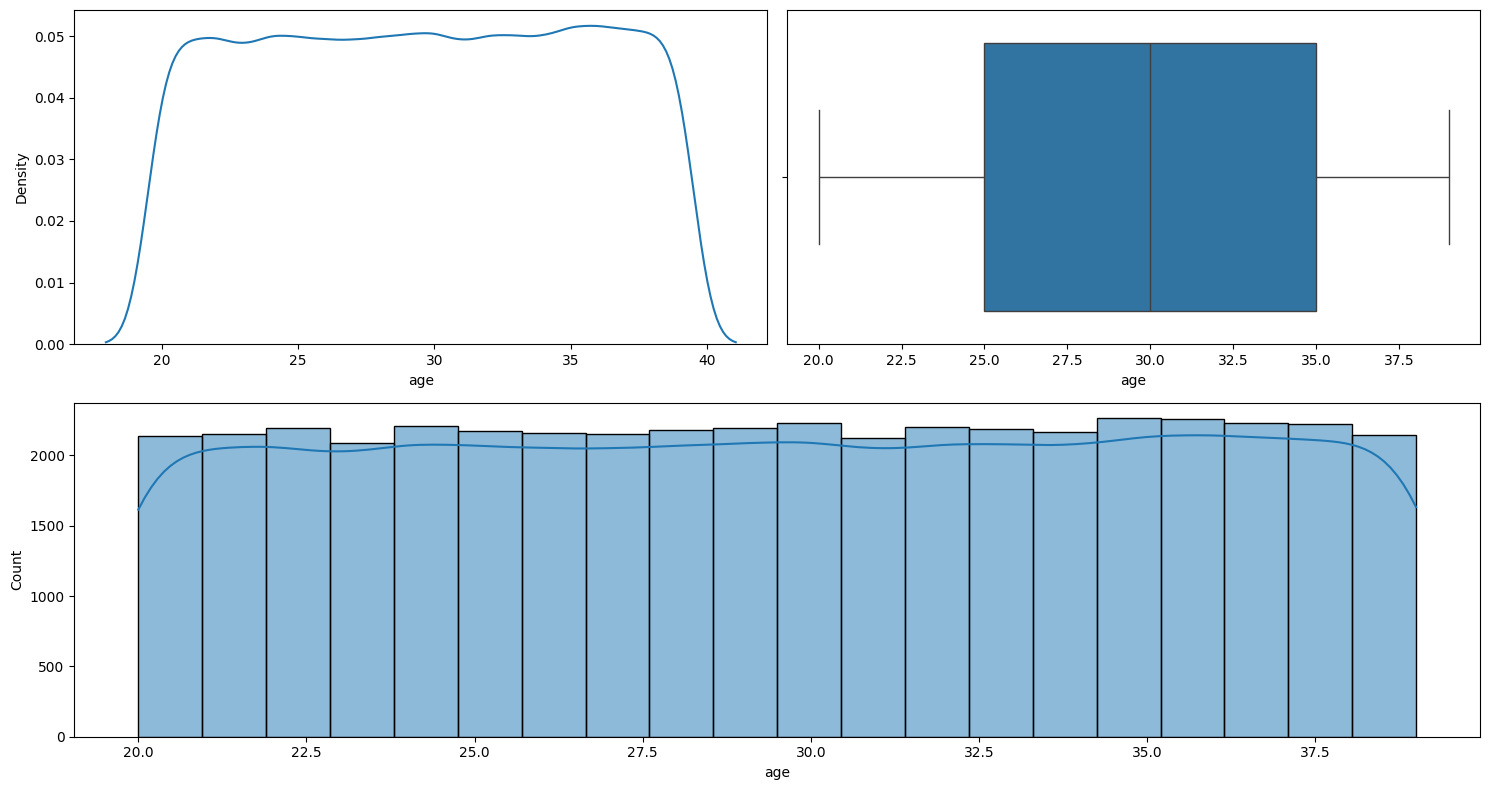

In [262]:
# numerical analysis of age column
numerical_analysis(df_final, "age",bins=20)

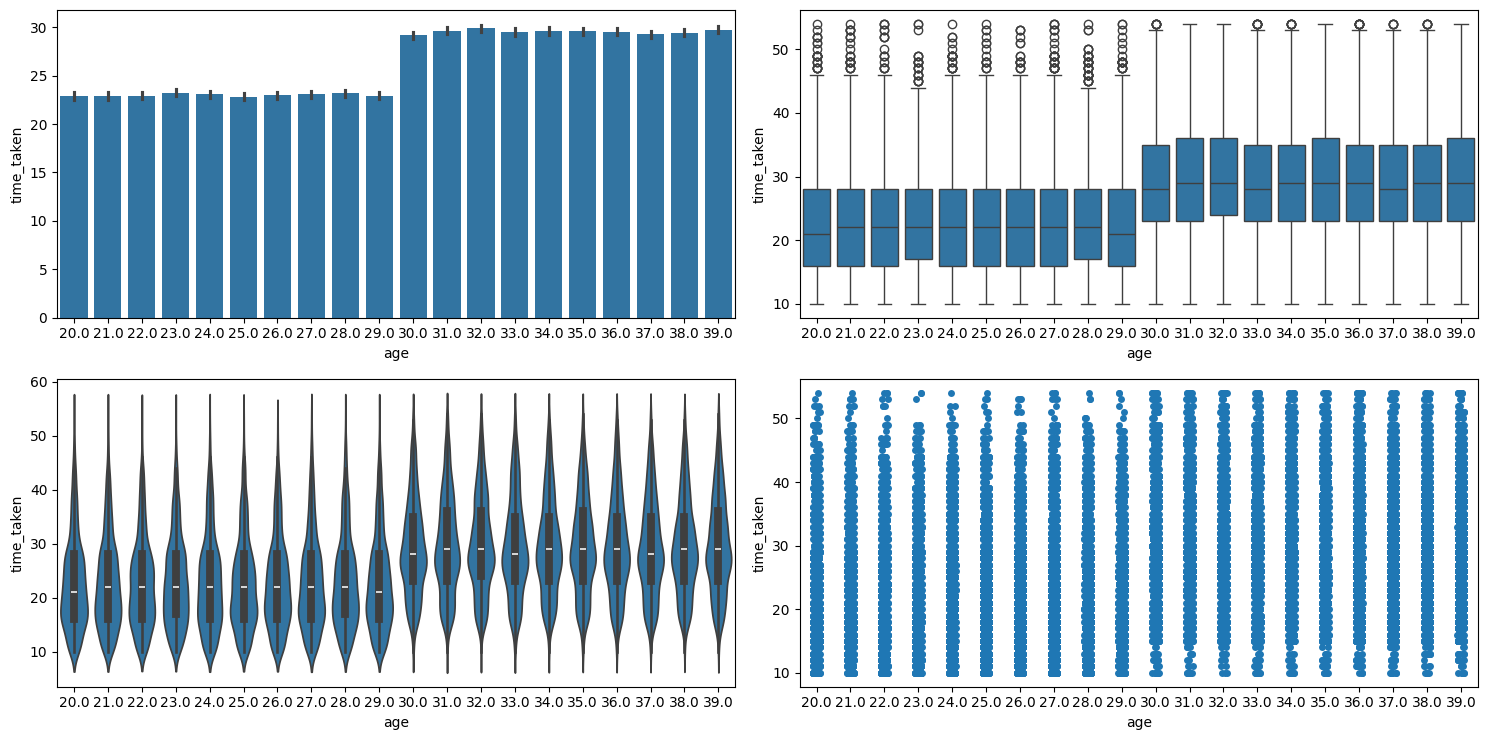

In [263]:
numerical_categorical_analysis(df_final,"age","time_taken")

**Observations**  
Based on all four visualizations, the time taken to deliver items does appear to vary across age groups.  
Specifically, riders above age 30 consistently show higher average delivery times and reduced variability.  
This pattern suggests that age may influence delivery efficiency, either directly or via other correlated factors.

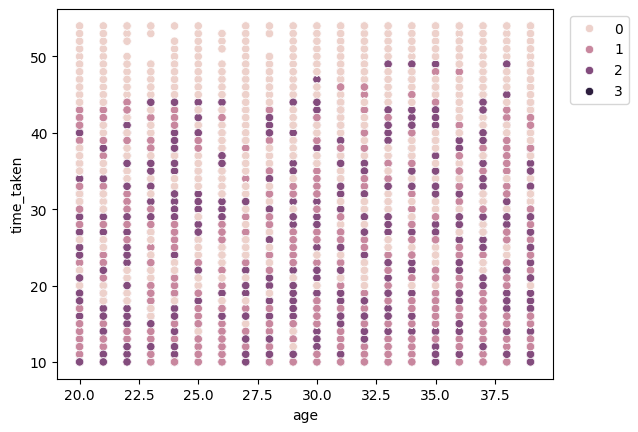

In [264]:
sns.scatterplot(data=df_final, x='age', y='time_taken', hue="vehicle_condition")
plt.legend(bbox_to_anchor=(1.02, 1), loc=2)
plt.show()

<Axes: xlabel='type_of_vehicle', ylabel='age'>

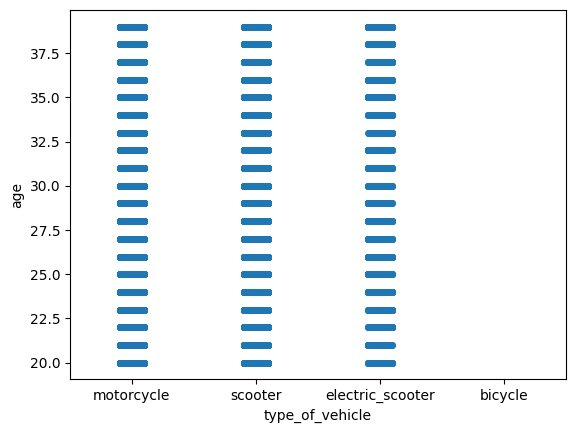

In [265]:
# preferences of vehicle type based on age

sns.stripplot(df_final,x='type_of_vehicle',y='age')

## Ratings

In [266]:
# data type of ratings column
df_final['ratings'].dtype

dtype('float64')

In [267]:
# statistical summary
df_final['ratings'].describe()

count    43594.000000
mean         4.635287
std          0.313827
min          2.500000
25%          4.500000
50%          4.700000
75%          4.900000
max          5.000000
Name: ratings, dtype: float64

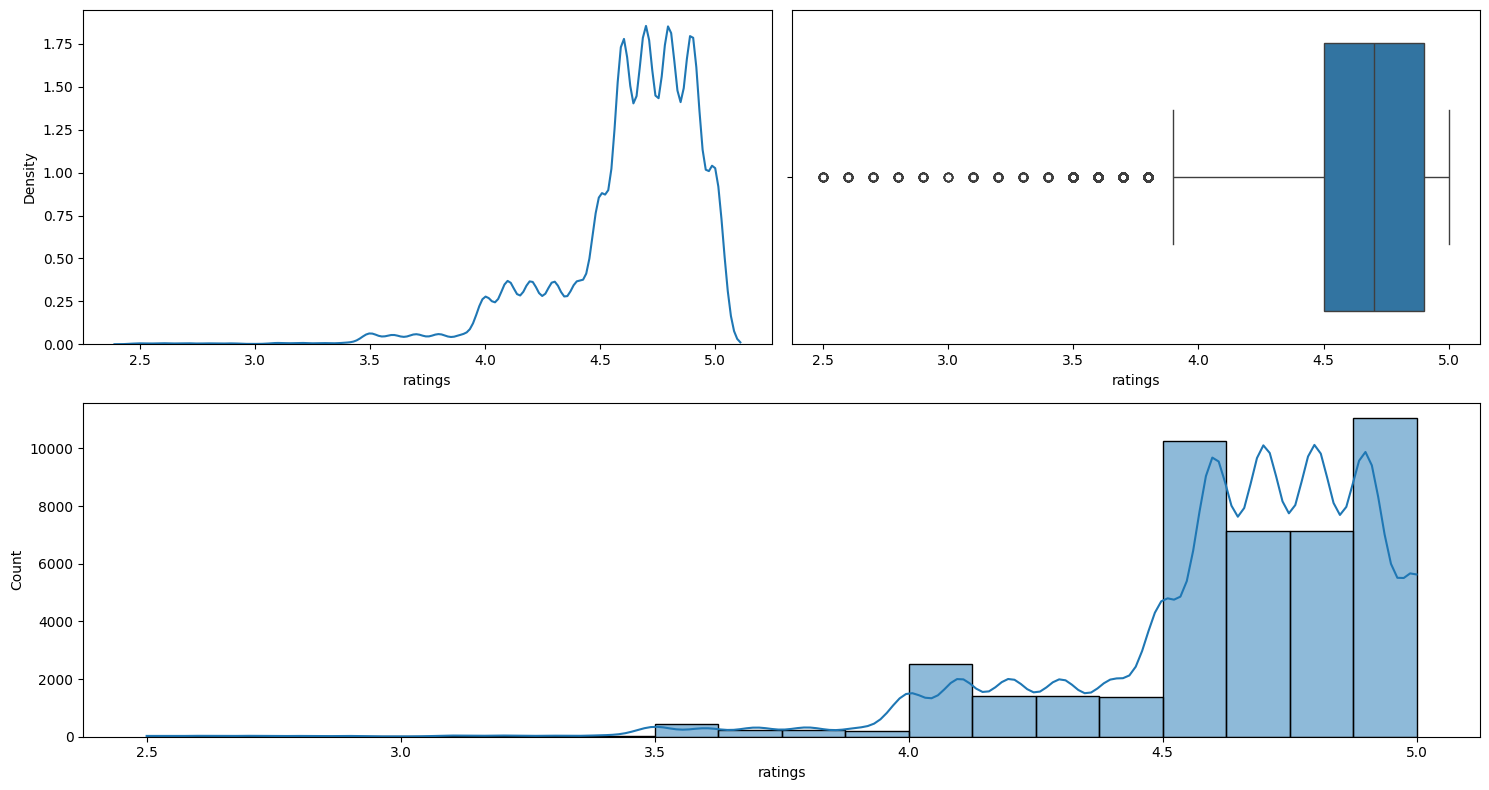

In [268]:
# numerical analysis of ratings column
numerical_analysis(df_final, "ratings",bins=20)

<Axes: xlabel='ratings', ylabel='time_taken'>

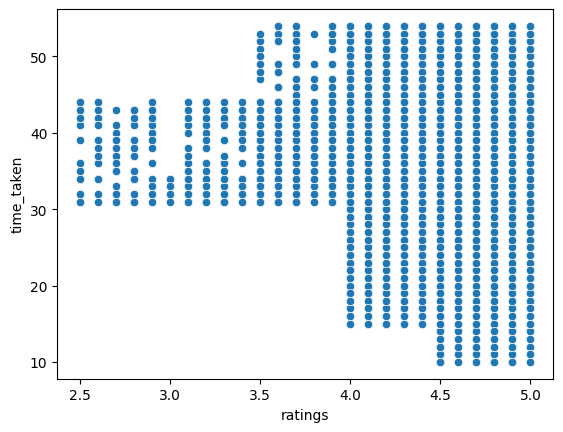

In [269]:
# does rating affect delivery time

sns.scatterplot(data=df_final, x='ratings', y='time_taken')

**It seems like riders with more ratings get more orders**  
**Higher ratings equates to more work and more income opportunities**

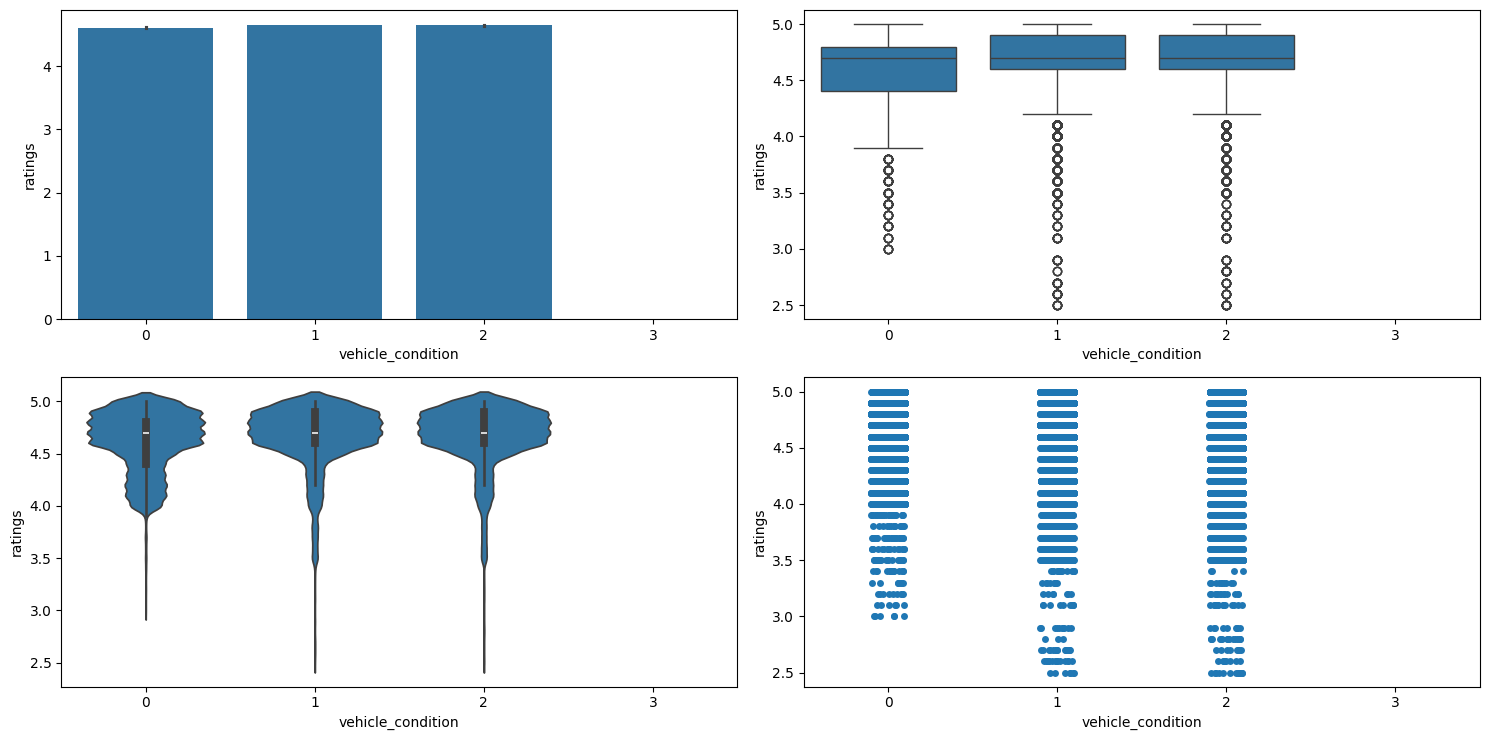

In [270]:
# does vehicle condition affect delivery time
numerical_categorical_analysis(df_final,"vehicle_condition","ratings")

# **Yes they do**

- The more worst the vehicle condition is, the more lower the rating gets.
- The category 3 has no data means there are NaN values. This simply means that customers avoid rating their riders even rating of 1 when the vehicle condition is bad.

In [271]:
(
    df_final[["ratings","vehicle_condition"]]
    .loc[(df_final['vehicle_condition']==3),"ratings"]
    .value_counts(dropna=False)
)


ratings
NaN    429
Name: count, dtype: int64

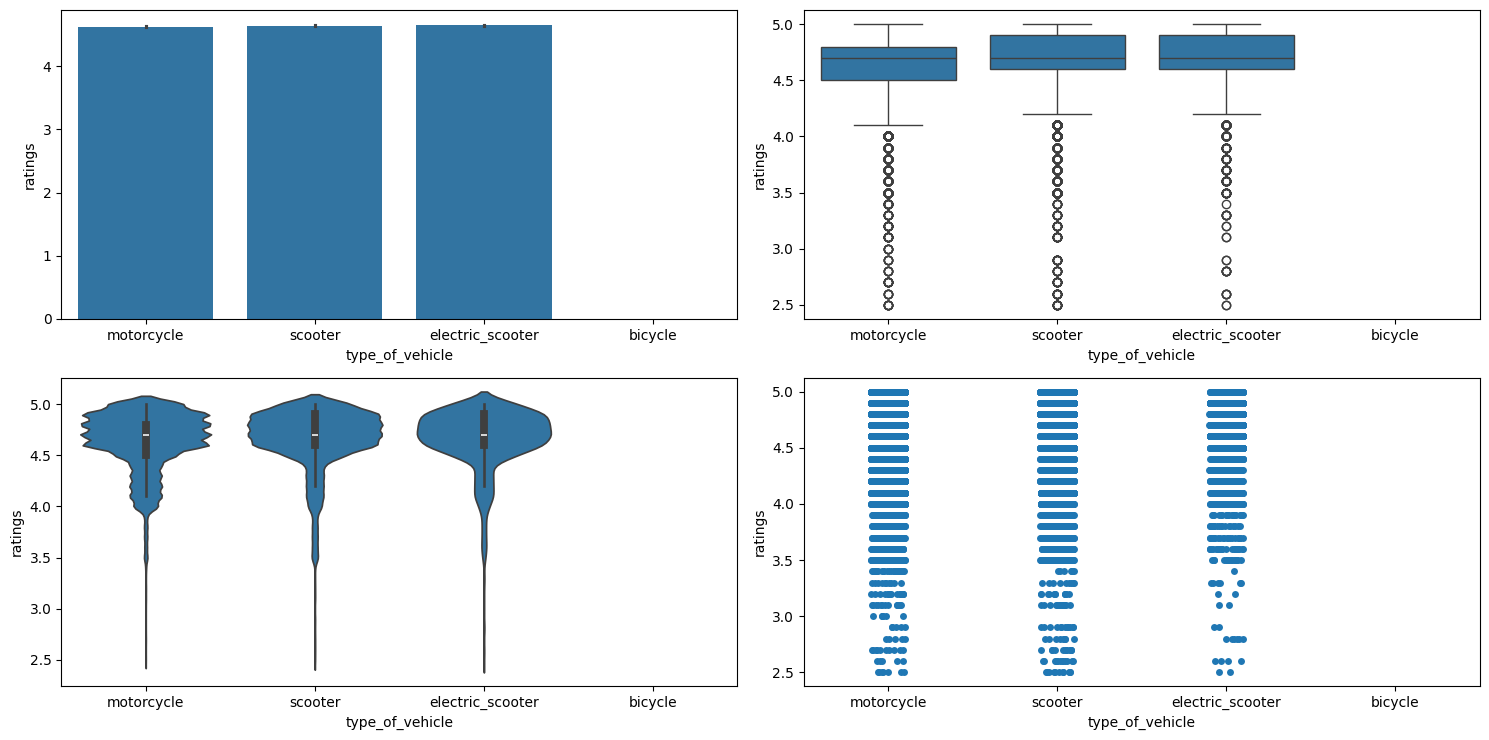

In [272]:
# does the type of vechicle affect delivery time
numerical_categorical_analysis(df_final,"type_of_vehicle","ratings")

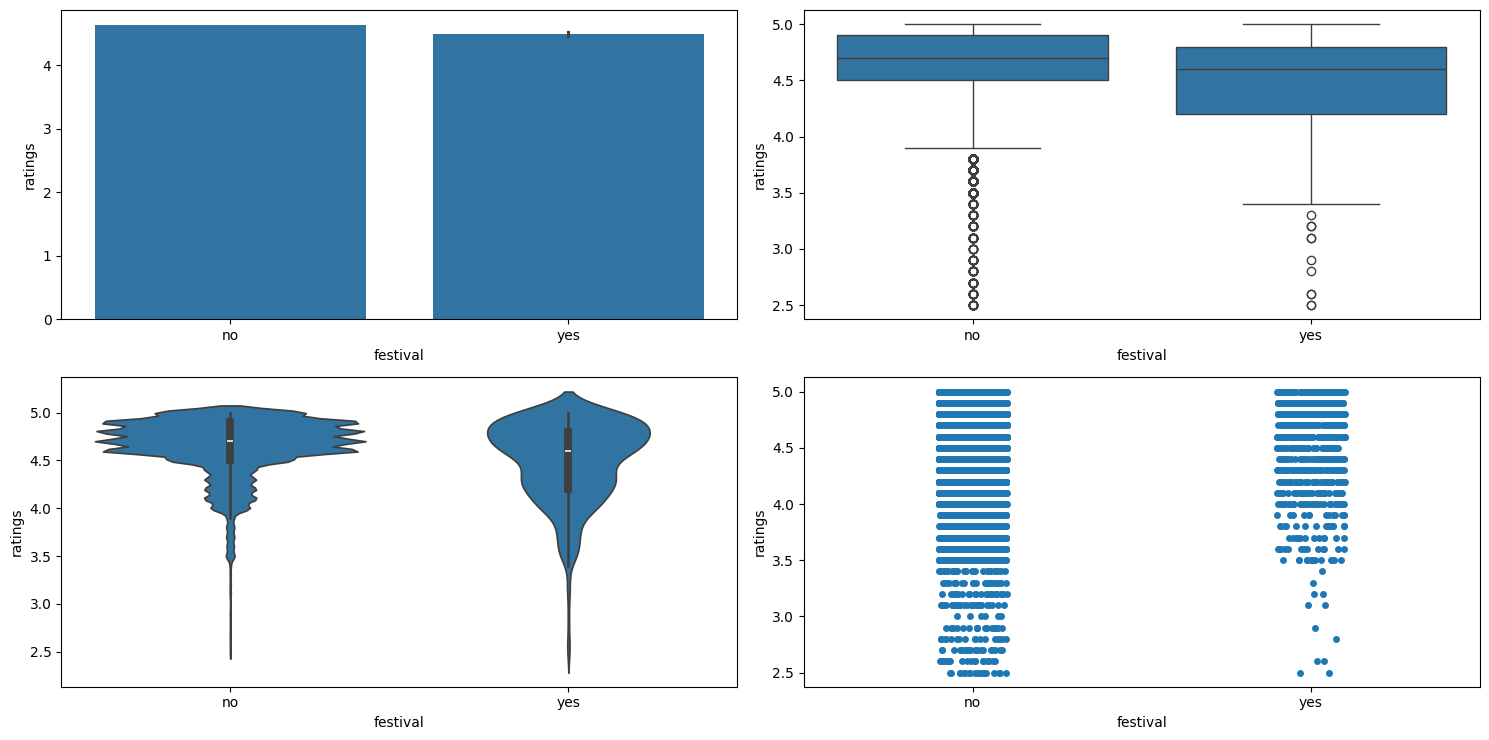

In [273]:
# festival and rider ratings

numerical_categorical_analysis(df_final,"festival","ratings")

## Location Based Features

In [274]:
df_final.columns[3:7].tolist()+["city_name"]

['restaurant_latitude',
 'restaurant_longitude',
 'delivery_latitude',
 'delivery_longitude',
 'city_name']

In [275]:
# location subset
location_subset = df_final.loc[:,df_final.columns[3:7].tolist()+["city_name"]]
display(location_subset.head(5))

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,city_name
0,22.745049,75.892471,22.765049,75.912471,INDO
1,12.913041,77.683237,13.043041,77.813237,BANG
2,12.914264,77.678400,12.924264,77.688400,BANG
3,11.003669,76.976494,11.053669,77.026494,COIMB
4,12.972793,80.249982,13.012793,80.289982,CHEN


In [276]:
location_subset.dtypes

restaurant_latitude     float64
restaurant_longitude    float64
delivery_latitude       float64
delivery_longitude      float64
city_name                object
dtype: object

In [277]:
# drop missing values

location_subset.dropna(inplace=True)

location_subset

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,city_name
0,22.745049,75.892471,22.765049,75.912471,INDO
1,12.913041,77.683237,13.043041,77.813237,BANG
2,12.914264,77.678400,12.924264,77.688400,BANG
3,11.003669,76.976494,11.053669,77.026494,COIMB
4,12.972793,80.249982,13.012793,80.289982,CHEN
...,...,...,...,...,...
45496,23.371292,85.327872,23.481292,85.437872,RANCHI
45497,26.902328,75.794257,26.912328,75.804257,JAP
45499,13.022394,80.242439,13.052394,80.272439,CHEN
45500,11.001753,76.986241,11.041753,77.026241,COIMB


In [278]:
# plot deliveries on map

delivery_df = pd.DataFrame({
    'latitude': location_subset['delivery_latitude'],
    'longitude': location_subset['delivery_longitude'],
    "city_name": location_subset["city_name"]
})


# Create a map using Plotly's scatter_mapbox
fig = px.scatter_mapbox(
    delivery_df,
    lat='latitude',
    lon='longitude',
    title="Delivery Points",
    hover_name="city_name"
)

# Update the layout for the map of India
fig.update_layout(
    mapbox_style="carto-positron",
    mapbox_center={"lat": 20.5937, "lon": 78.9629},  # Centered over India
    mapbox_zoom=3,
)

# Show the plot
fig.show()

In [279]:
delivery_df['city_name'].value_counts()

city_name
JAP       3439
BANG      3184
SUR       3182
HYD       3177
MUM       3168
COIMB     3162
INDO      3154
CHEN      3132
PUNE      3129
MYS       3005
RANCHI    2559
VAD       1576
KOC        701
KOL        699
LUDH       687
KNP        673
GOA        609
ALH        566
AURG       555
AGR        548
DEH        491
BHP        476
Name: count, dtype: int64

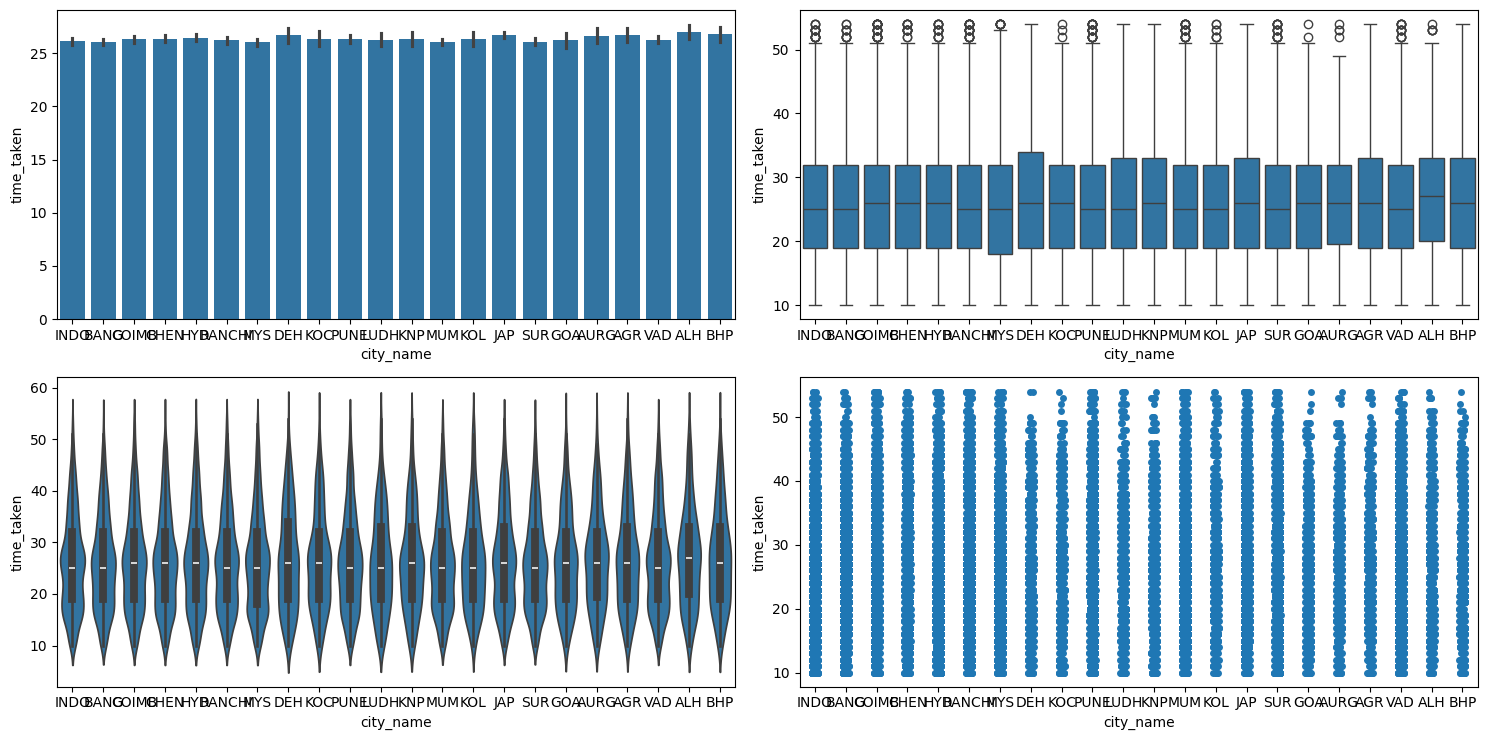

In [280]:
numerical_categorical_analysis(df_final,"city_name","time_taken")

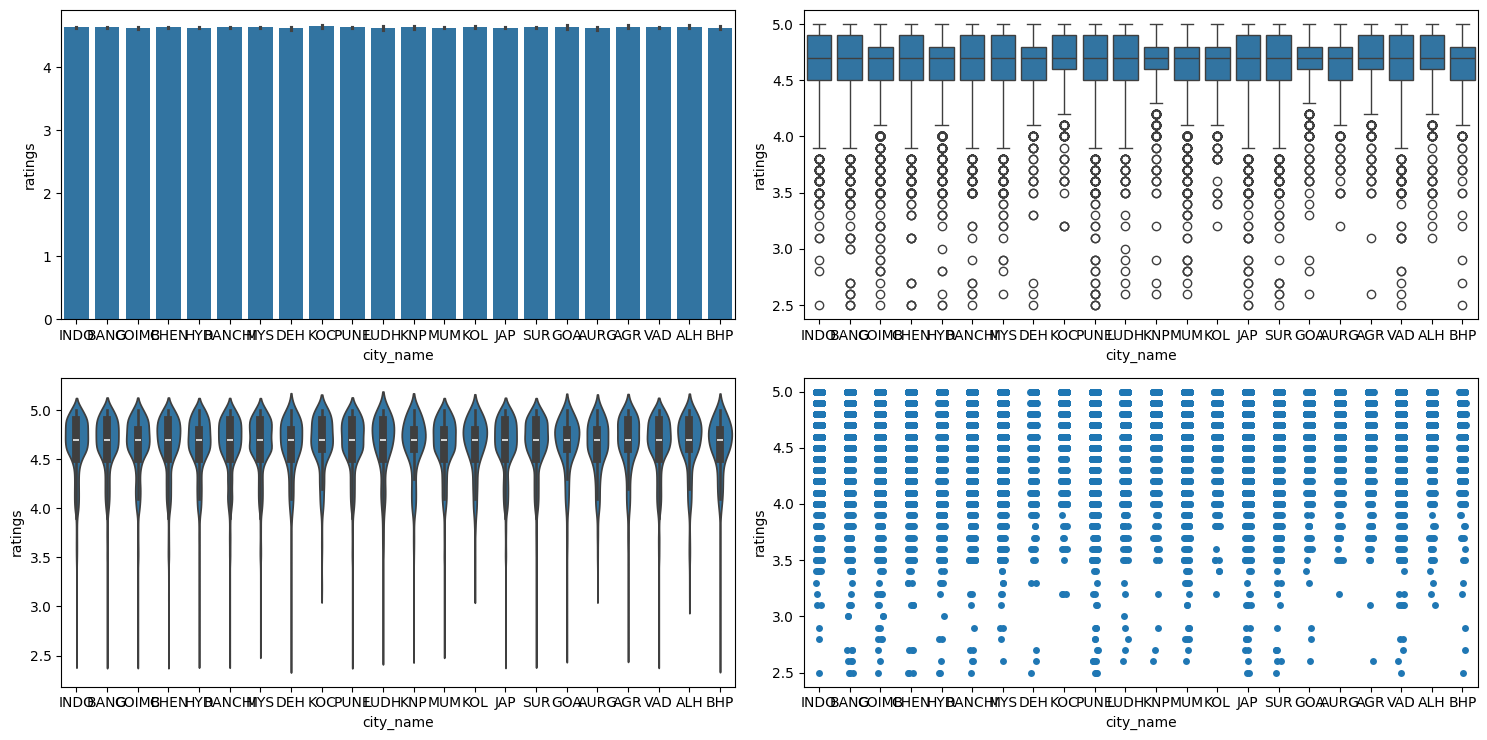

In [281]:
numerical_categorical_analysis(df_final,"city_name","ratings")

## Order Date

In [282]:
df_final.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutes',
       'order_time_hour', 'order_time_of_day', 'distance', 'time_taken_pt'],
      dtype='object')

In [283]:
# order date columns

order_date_subset = df_final.loc[:,["order_date","order_day","order_month","order_day_of_week","is_weekend","festival"]]

order_date_subset

,order_date,order_day,order_month,order_day_of_week,is_weekend,festival
0,2022-03-19,19,3,saturday,1,no
1,2022-03-25,25,3,friday,0,no
2,2022-03-19,19,3,saturday,1,no
3,2022-04-05,5,4,tuesday,0,no
4,2022-03-26,26,3,saturday,1,no
...,...,...,...,...,...,...
45497,2022-03-24,24,3,thursday,0,no
45498,2022-02-16,16,2,wednesday,0,no
45499,2022-03-11,11,3,friday,0,no
45500,2022-03-07,7,3,monday,0,no


,Count,Percentage
order_day_of_week,,
wednesday,7077,15.55%
friday,7020,15.43%
tuesday,6363,13.98%
thursday,6338,13.93%
saturday,6276,13.79%
sunday,6231,13.69%
monday,6197,13.62%


**************************************************
Number of unique values in order_day_of_week: 7
**************************************************
Unique values in order_day_of_week: ['saturday' 'friday' 'tuesday' 'monday' 'sunday' 'wednesday' 'thursday']
**************************************************


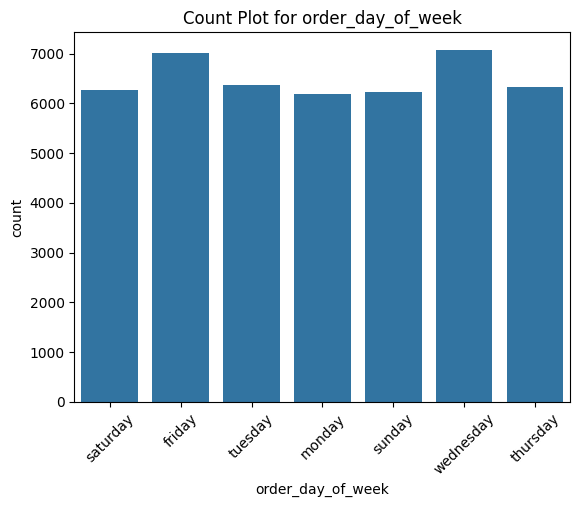

In [284]:
# analysis of order_day_of_week
categorical_analysis(order_date_subset,"order_day_of_week")

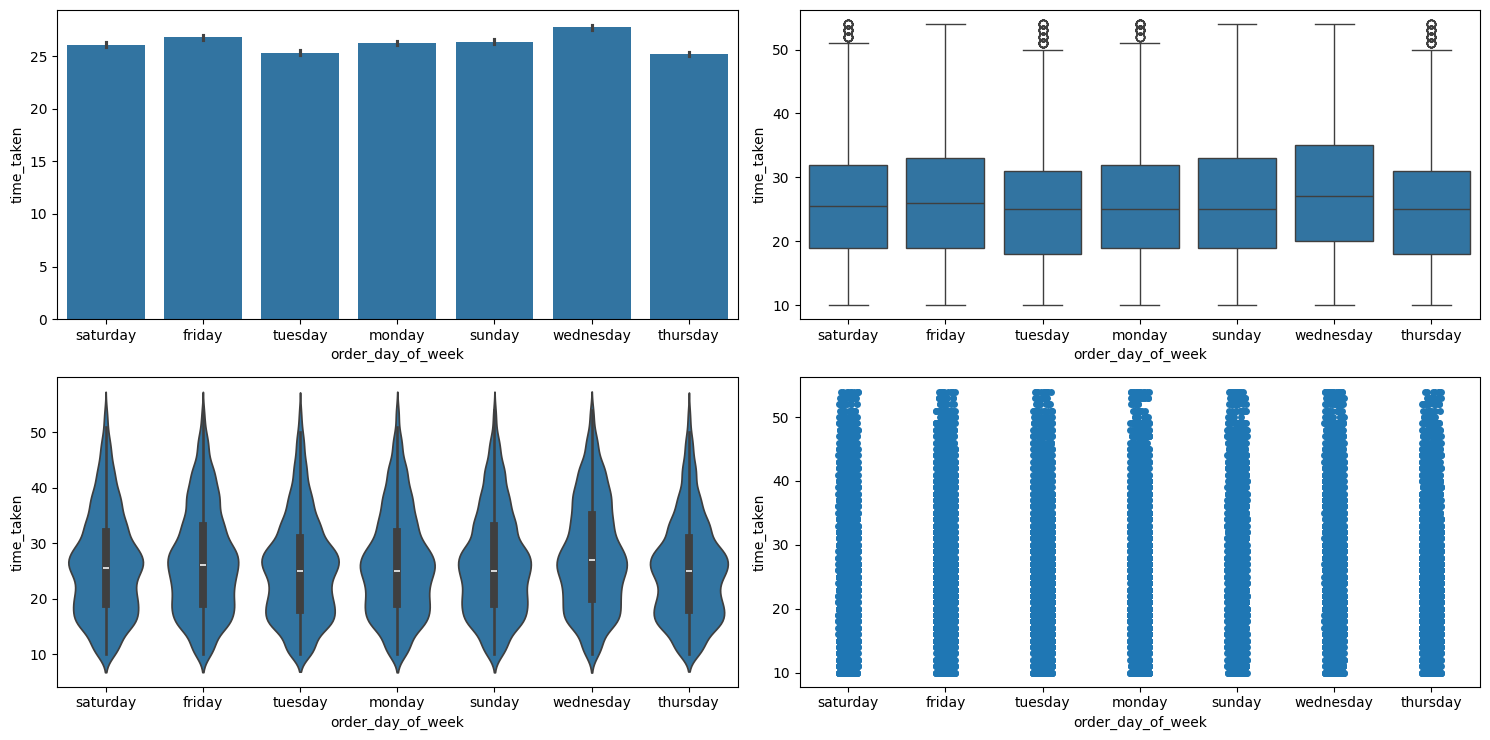

In [285]:
# analysis between day of week and target

numerical_categorical_analysis(df_final,"order_day_of_week","time_taken")

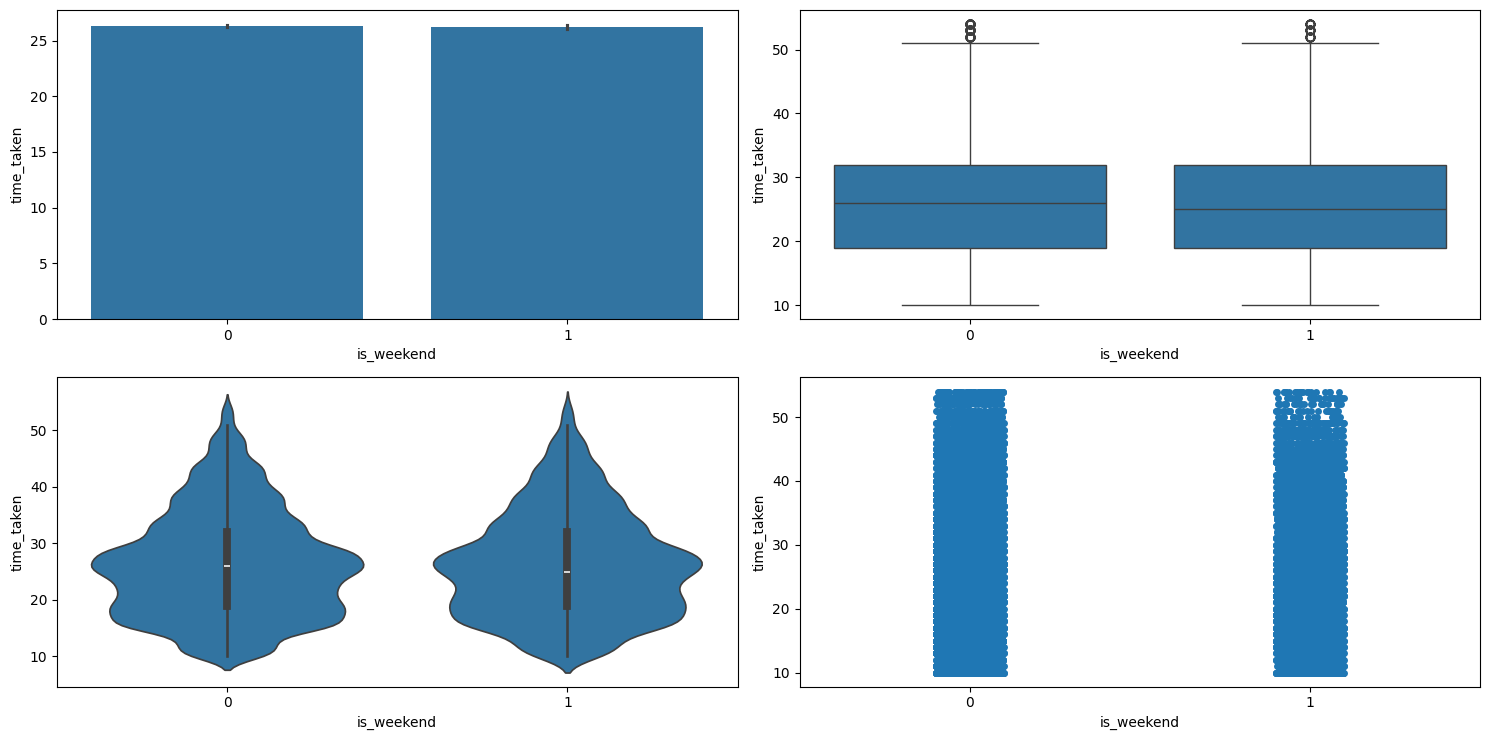

In [286]:
# analysis between is_weekend and target

numerical_categorical_analysis(df_final,"is_weekend","time_taken")

**Distribution of data for timetaken in weekdays/weekends are the same**

In [290]:
# do weekends have an impact on traffic

chi2_test(df_final, "is_weekend", "traffic")

Chi-Squared test results for is_weekend and traffic:
Chi2 statistic: 1.4899
Degrees of freedom: 3
Expected frequencies:
[[ 3207.31852329 10251.09737287 11218.0042452   7934.57985864]
 [ 1217.68147671  3891.90262713  4258.9957548   3012.42014136]]
p-value: 0.6846
Fail to reject the null hypothesis at alpha = 0.05


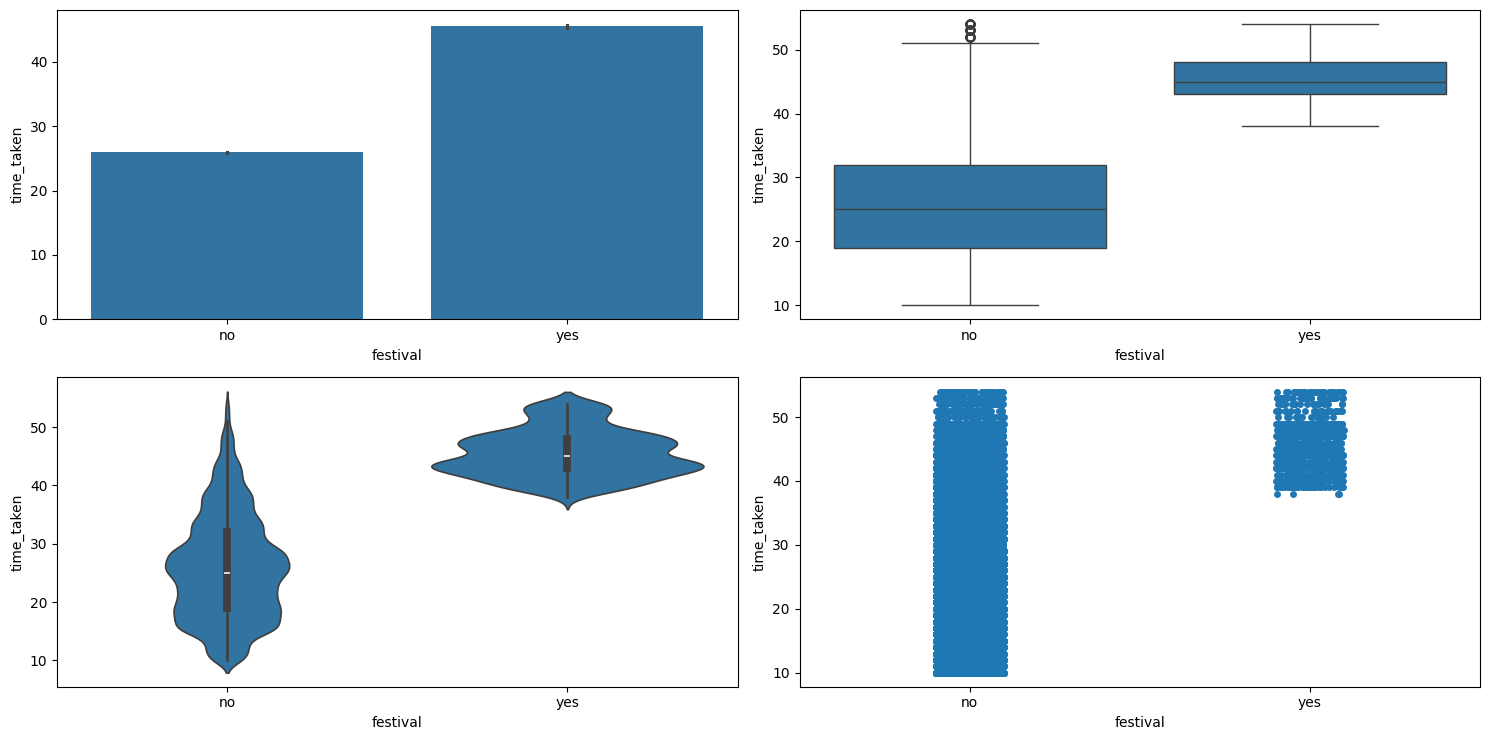

In [291]:
# do festivals and target analysis
numerical_categorical_analysis(df_final,"festival","time_taken")

**Observations:**
1. The avg time on festive season to deliver the item is much greater compared off festive season


In [294]:
# do festival affect traffic

chi2_test(df_final, "festival", "traffic")

Chi-Squared test results for festival and traffic:
Chi2 statistic: 710.4774
Degrees of freedom: 3
Expected frequencies:
[[ 4320.46855943 13826.08760918 15047.62240043 10693.82143096]
 [   86.53144057   276.91239082   301.37759957   214.17856904]]
p-value: 0.0000
Reject the null hypothesis at alpha = 0.05


The p value is very small which mans it does affect traffic.

In [295]:
df_final.pivot_table(index="traffic",columns="festival",values="time_taken",aggfunc="mean")

festival,no,yes
traffic,,
high,27.010373,45.826087
jam,30.538039,46.093651
low,21.284332,42.020000
medium,26.550288,43.715385


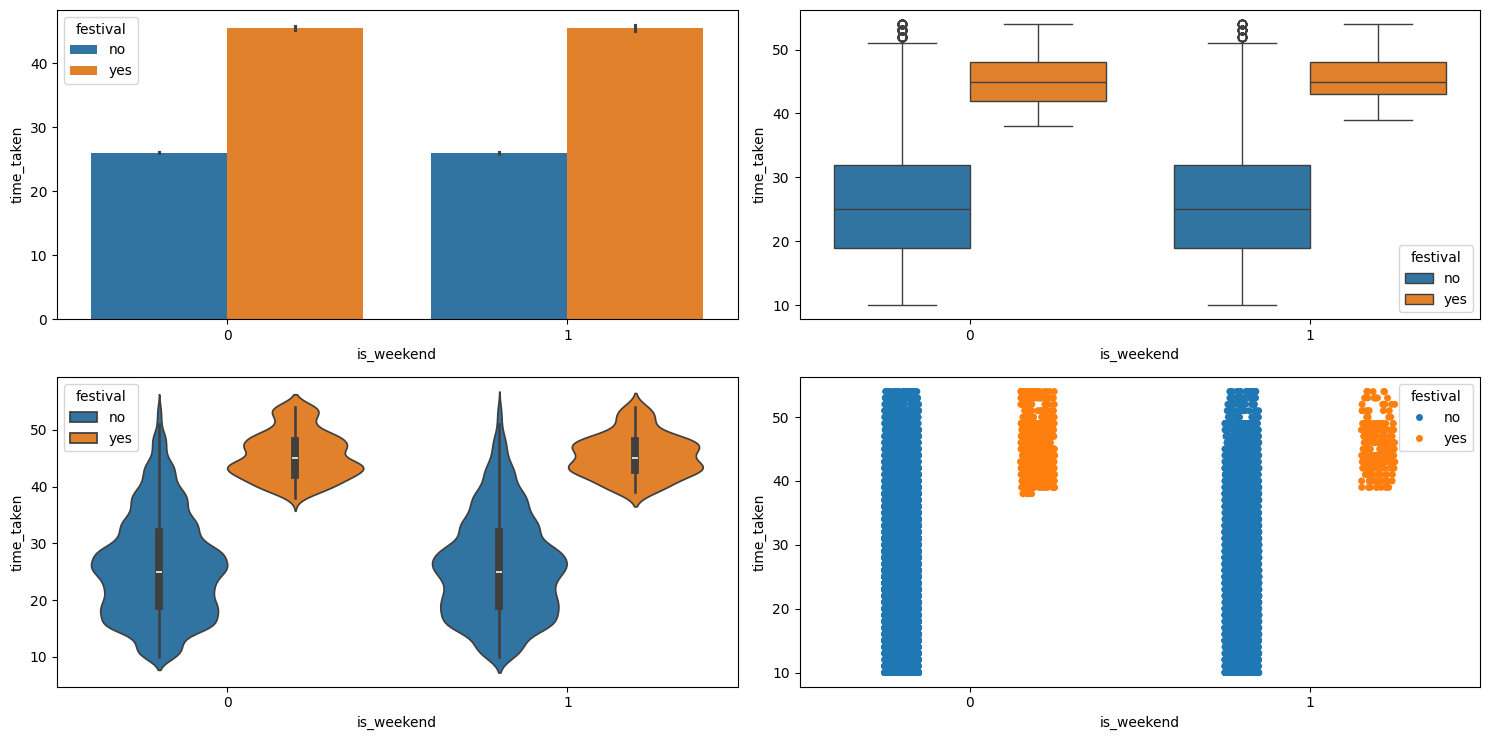

In [298]:
# does a weekend and a festival combined have an effect on delivery times

multivariate_analysis(df_final, "time_taken", "is_weekend", "festival")

## Order Time

In [299]:
df_final.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutes',
       'order_time_hour', 'order_time_of_day', 'distance', 'time_taken_pt'],
      dtype='object')

In [300]:
# time related columns

time_subset = df_final.loc[:,["order_time_hour","order_time_of_day","pickup_time_minutes"]]

time_subset

,order_time_hour,order_time_of_day,pickup_time_minutes
0,11.0,morning,15.0
1,19.0,evening,5.0
2,8.0,morning,15.0
3,18.0,evening,10.0
4,13.0,afternoon,15.0
...,...,...,...
45497,11.0,morning,10.0
45498,19.0,evening,15.0
45499,23.0,night,15.0
45500,13.0,afternoon,5.0


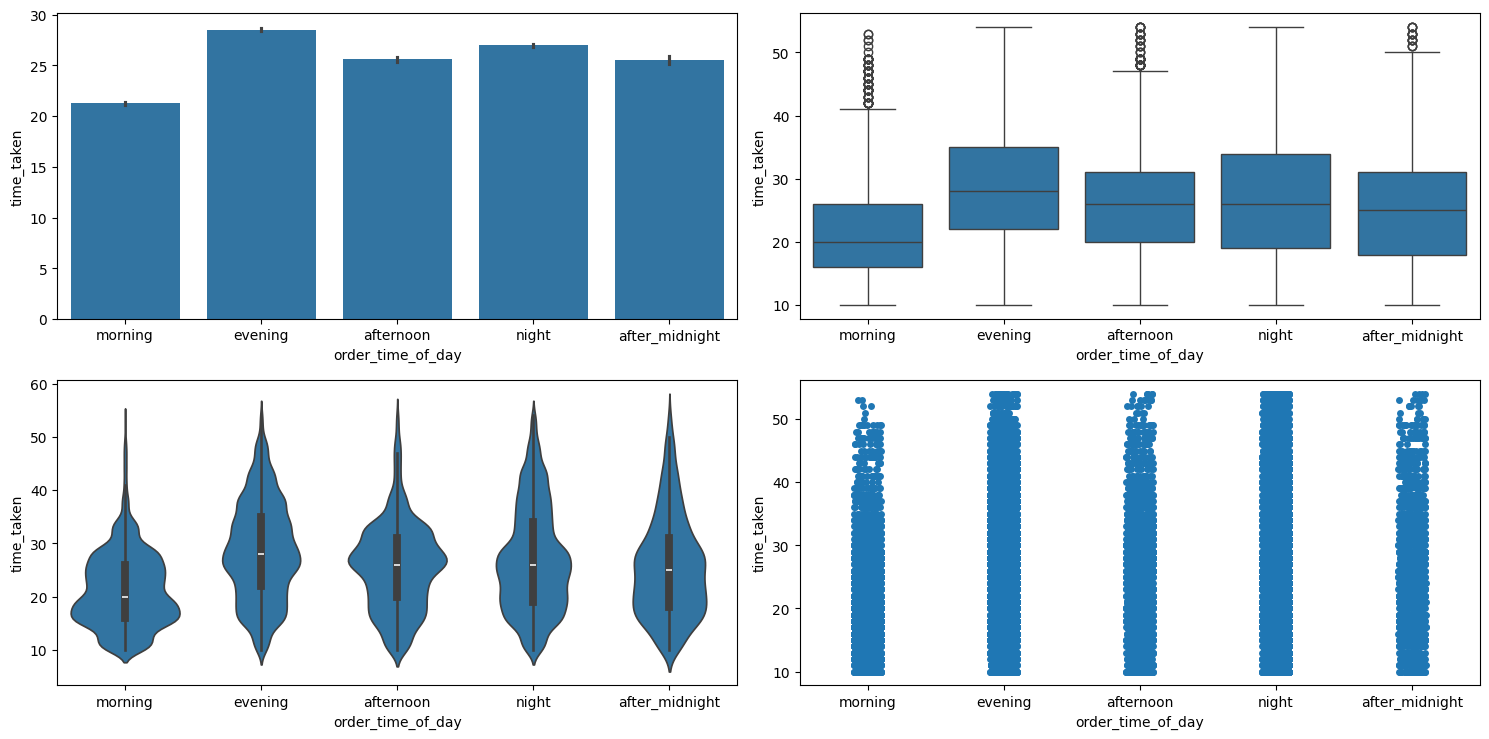

In [301]:
# does order time hour effect delivery time
numerical_categorical_analysis(df_final,"order_time_of_day","time_taken")

In [303]:
# anova test

anova_test(df_final, "order_time_of_day","time_taken")

ANOVA test results for order_time_of_day and time_taken:
F-statistic: 834.7126
p-value: 0.0000
Reject the null hypothesis at alpha = 0.05


In [306]:
# top 5 time(hrs) of the day in which cutomers orders the most
df_final['order_time_hour'].value_counts()

order_time_hour
21.0    4686
19.0    4595
22.0    4576
20.0    4539
23.0    4511
18.0    4480
17.0    4278
10.0    1991
11.0    1962
9.0     1947
8.0     1818
12.0     892
15.0     873
14.0     791
13.0     784
16.0     709
0.0      430
Name: count, dtype: int64

,Count,Percentage
order_time_hour,,
21.0,4686,10.68%
19.0,4595,10.48%
22.0,4576,10.43%
20.0,4539,10.35%
23.0,4511,10.28%
18.0,4480,10.21%
17.0,4278,9.75%
10.0,1991,4.54%
11.0,1962,4.47%


**************************************************
Number of unique values in order_time_hour: 17
**************************************************
Unique values in order_time_hour: [11. 19.  8. 18. 13. 21. 17. 20. 14.  9. 22. 12. 23. nan 10. 16. 15.  0.]
**************************************************


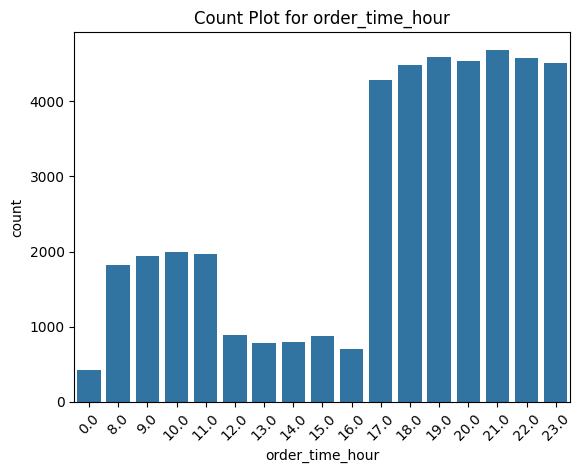

In [307]:
# categorical analysis on order_time_hour

categorical_analysis(df_final, "order_time_hour")

,Count,Percentage
order_time_of_day,,
night,18312,40.24%
evening,13353,29.35%
morning,7718,16.96%
afternoon,4049,8.9%
after_midnight,2070,4.55%


**************************************************
Number of unique values in order_time_of_day: 5
**************************************************
Unique values in order_time_of_day: ['morning' 'evening' 'afternoon' 'night' 'after_midnight']
**************************************************


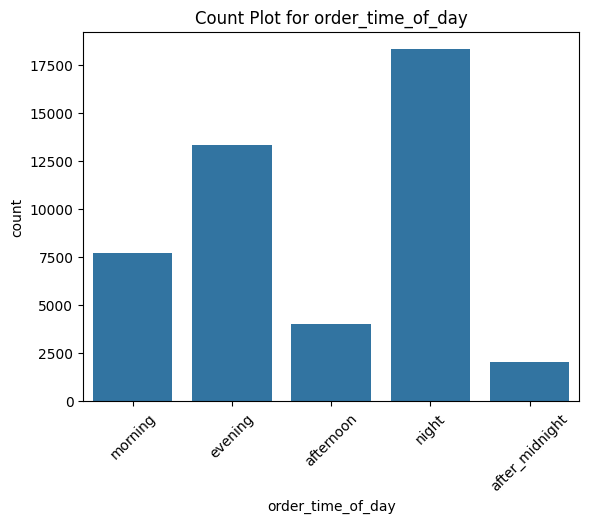

In [308]:
# categorical analysis on the time of day
categorical_analysis(df_final,"order_time_of_day")

## Pickup Time

In [309]:
# pickup_time datatypes

df_final['pickup_time_minutes'].dtype

dtype('float64')

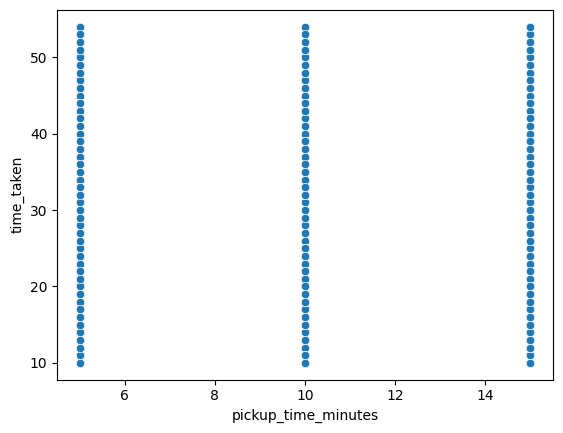

In [310]:
# relationship between pickup time and delivery time

sns.scatterplot(df_final,x="pickup_time_minutes",y="time_taken")
plt.show()

**Convert the column to ordinal categorical column**

,Count,Percentage
pickup_time_minutes,,
5.0,14703,33.52%
15.0,14610,33.31%
10.0,14549,33.17%


**************************************************
Number of unique values in pickup_time_minutes: 3
**************************************************
Unique values in pickup_time_minutes: [15.  5. 10. nan]
**************************************************


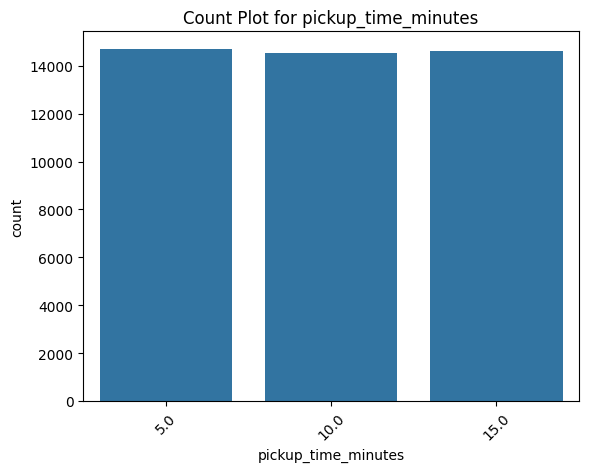

In [311]:
# pickup time categorical analysis
categorical_analysis(df_final,"pickup_time_minutes")

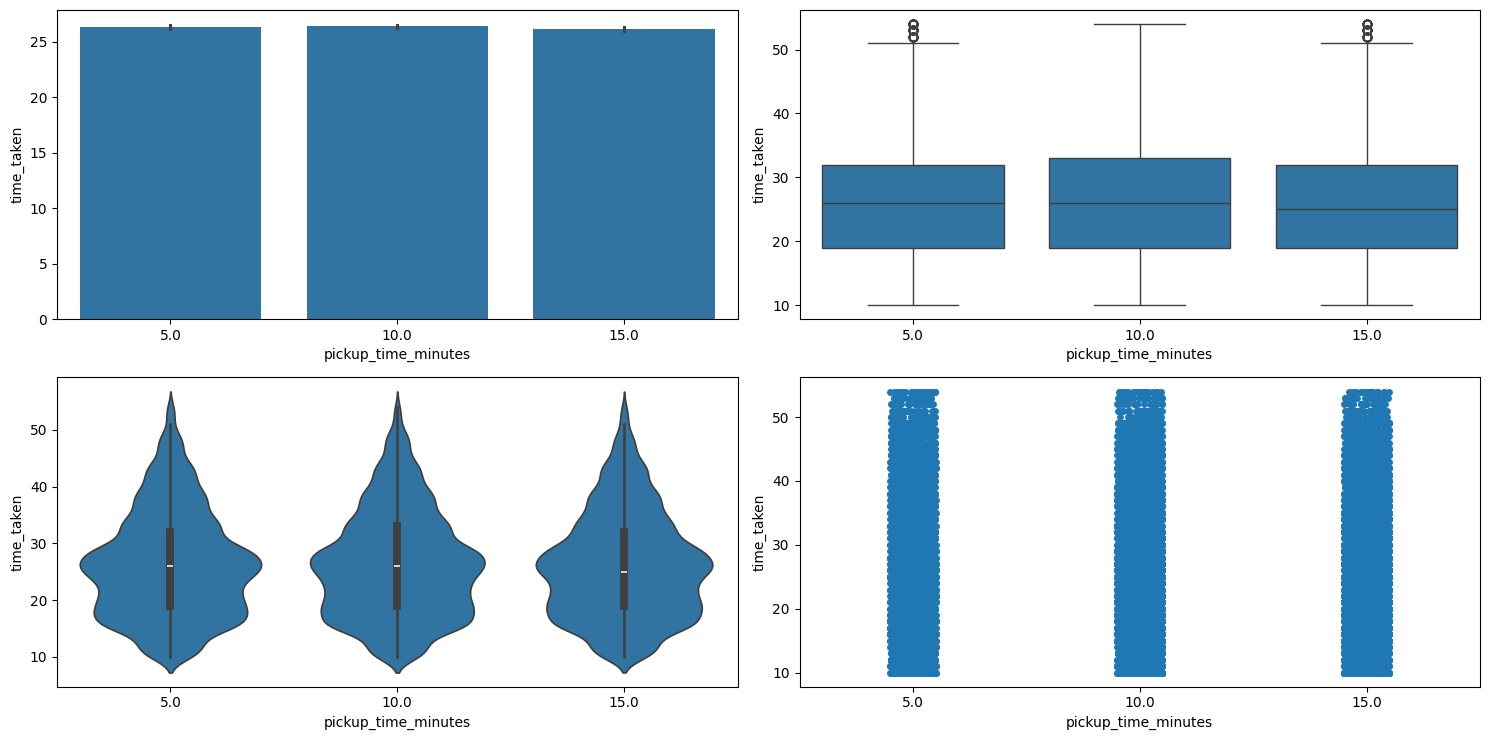

In [312]:
# does pickup time have an effect on delivery time

numerical_categorical_analysis(df_final,"pickup_time_minutes","time_taken")

In [313]:
# hypothesis testing for pickup time and delivery time
anova_test(df_final,"pickup_time_minutes","time_taken")

ANOVA test results for pickup_time_minutes and time_taken:
F-statistic: 2.3095
p-value: 0.0993
Fail to reject the null hypothesis at alpha = 0.05


## Traffic

In [314]:
# datatype of traffic column
df_final["traffic"].dtype

dtype('O')

,Count,Percentage
traffic,,
low,15477,34.4%
jam,14143,31.43%
medium,10947,24.33%
high,4425,9.84%


**************************************************
Number of unique values in traffic: 4
**************************************************
Unique values in traffic: ['high' 'jam' 'low' 'medium' nan]
**************************************************


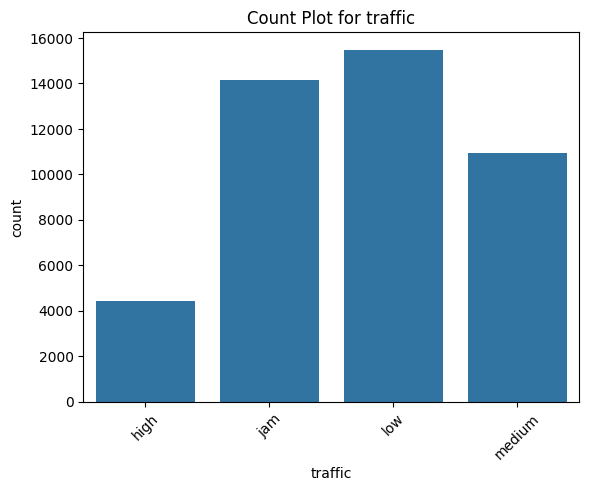

In [315]:
# categorical analysis of traffic column
categorical_analysis(df_final,"traffic")

In [316]:
# does traffic depends on the type of city 

chi2_test(df_final,"traffic","city_type")

Chi-Squared test results for traffic and city_type:
Chi2 statistic: 497.9373
Degrees of freedom: 6
Expected frequencies:
[[ 3321.22162372    16.09798462   989.68039166]
 [10632.20751832    51.53438477  3168.25809691]
 [11471.14794696    55.60073494  3418.2513181 ]
 [ 8204.42291101    39.76689567  2444.81019332]]
p-value: 0.0000
Reject the null hypothesis at alpha = 0.05


In [317]:
# does traffic depends on city
chi2_test(df_final,"traffic","city_name")

Chi-Squared test results for traffic and city_name:
Chi2 statistic: 62.3959
Degrees of freedom: 63
Expected frequencies:
[[  74.35321835   71.8944479    68.74722173  308.72321746   67.27195946
   304.29743065  307.54300765   71.50104463   69.140625    309.11662073
   306.55949947  335.08123666   72.09114954   68.35381846   67.96041518
    74.25486753  307.34630601  306.95290274  303.70732575  312.85395181
   309.80507646  307.44465683]
 [ 237.64464794  229.78602863  219.72699591  986.72824058  215.01182432
   972.58272582  982.95610331  228.52864954  220.984375    987.98561967
   979.81265558 1070.97263958  230.41471817  218.46961682  217.21223773
   237.33030317  982.32741376  981.07003467  970.69665718  999.93072102
   990.18603307  982.64175853]
 [ 260.05983286  251.45997066  240.45214705 1079.79869755  235.29222973
  1064.31894559 1075.67076369  250.08399271  241.828125   1081.1746755
  1072.23081881 1171.98922031  252.14795964  239.0761691   237.70019115
   259.71583837 1074.98277

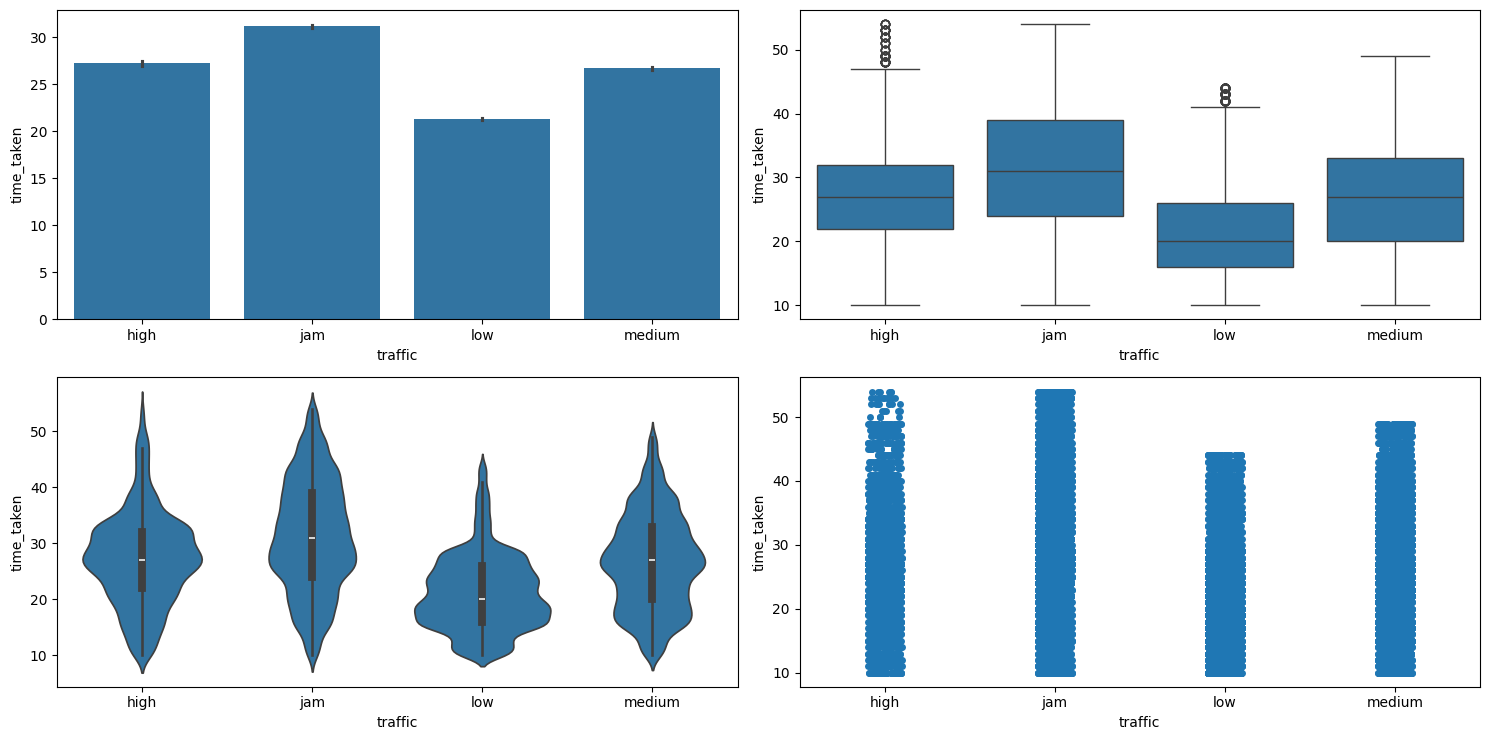

In [318]:
# does traffic affect delivery times

numerical_categorical_analysis(df_final,"traffic","time_taken")

In [320]:
# hypothesis test on does traffic affects delivery times

anova_test(df_final, "traffic","time_taken")

ANOVA test results for traffic and time_taken:
F-statistic: 3411.2667
p-value: 0.0000
Reject the null hypothesis at alpha = 0.05


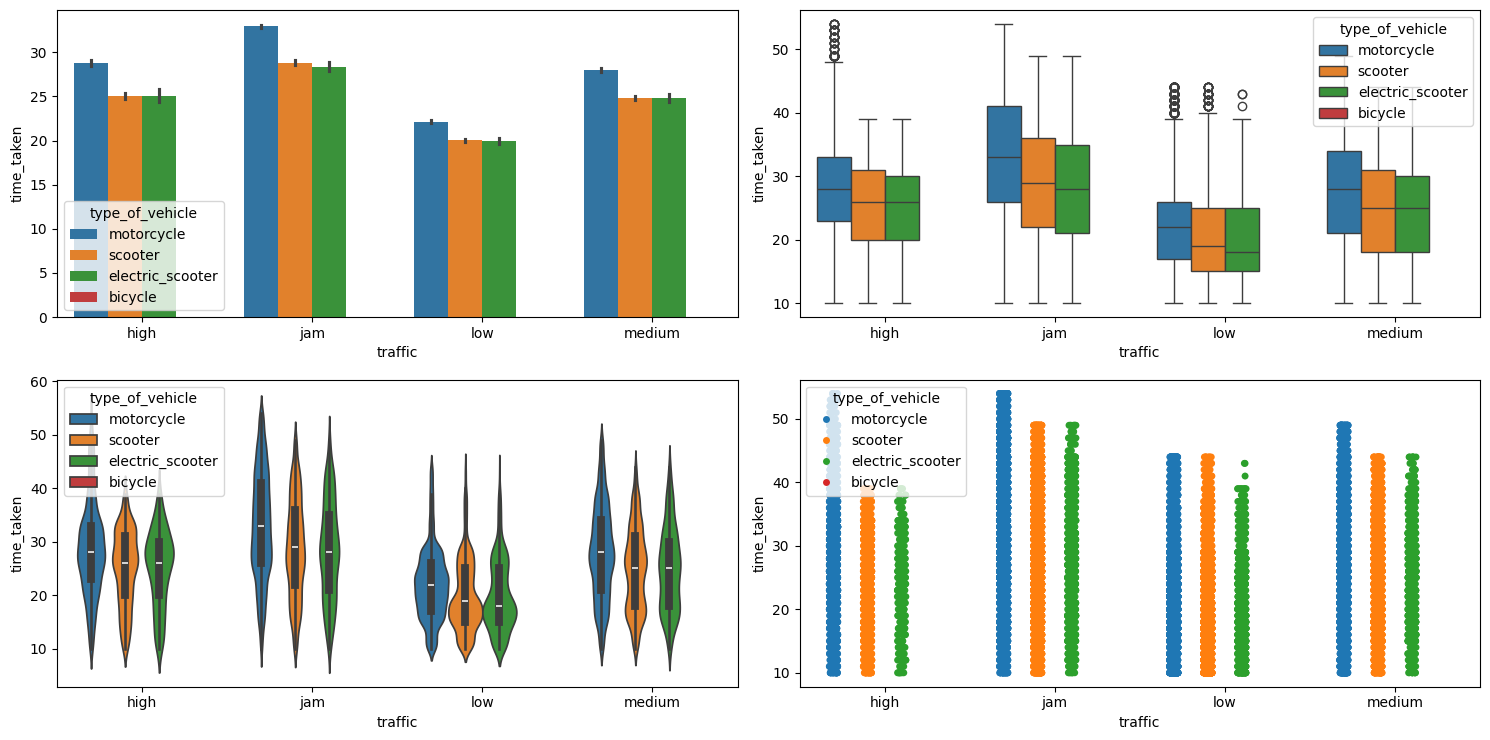

In [321]:
# are some vehicle types more suitable in traffic than others

multivariate_analysis(df_final, "time_taken", "traffic", "type_of_vehicle")

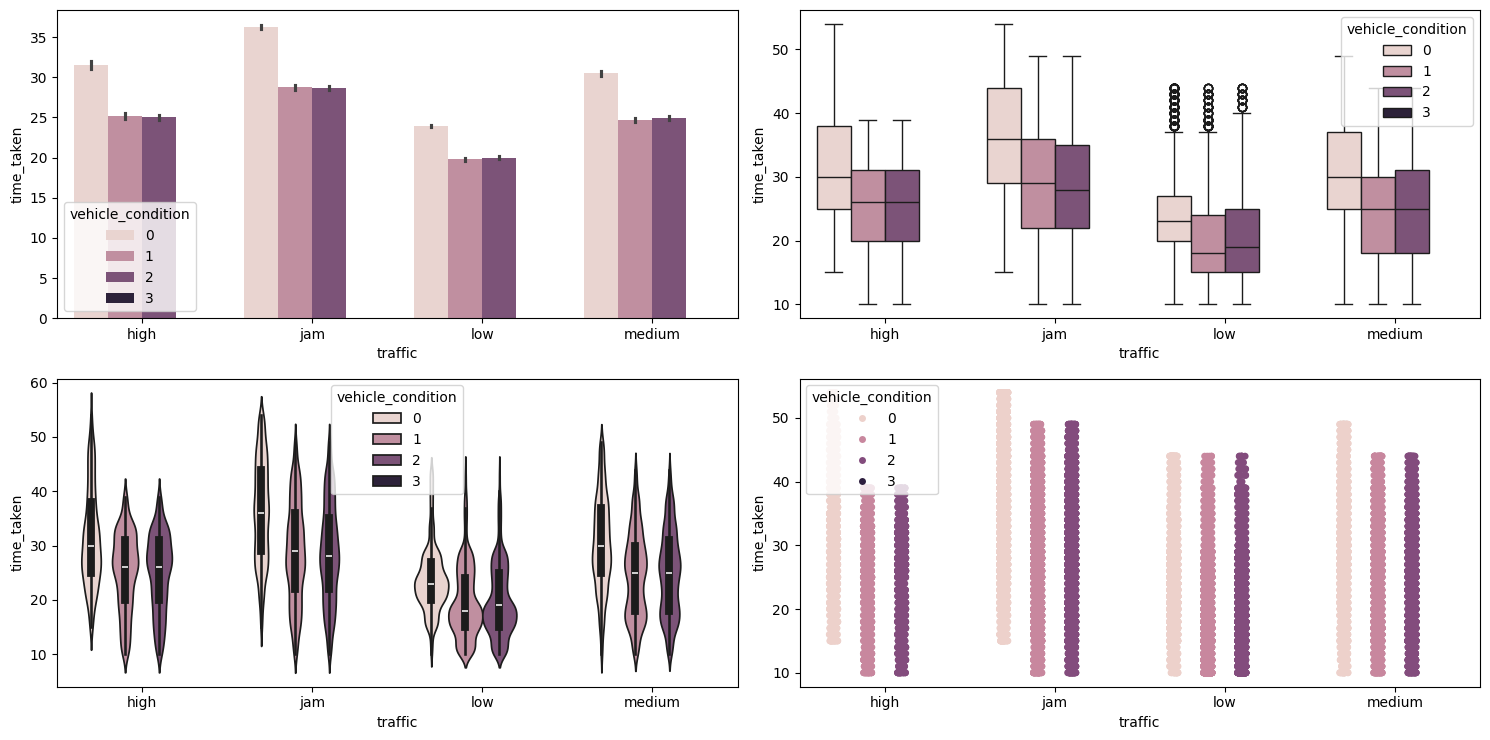

In [322]:
# does vehicle condition in traffic situations affects delivery times

multivariate_analysis(df_final, "time_taken", "traffic", "vehicle_condition")

**Dont make wrong interpretations that good condition vehicles takes longer times on avg**

This simply means that good vehicles are preferred for deliveries during festivals which results in longer delivery times

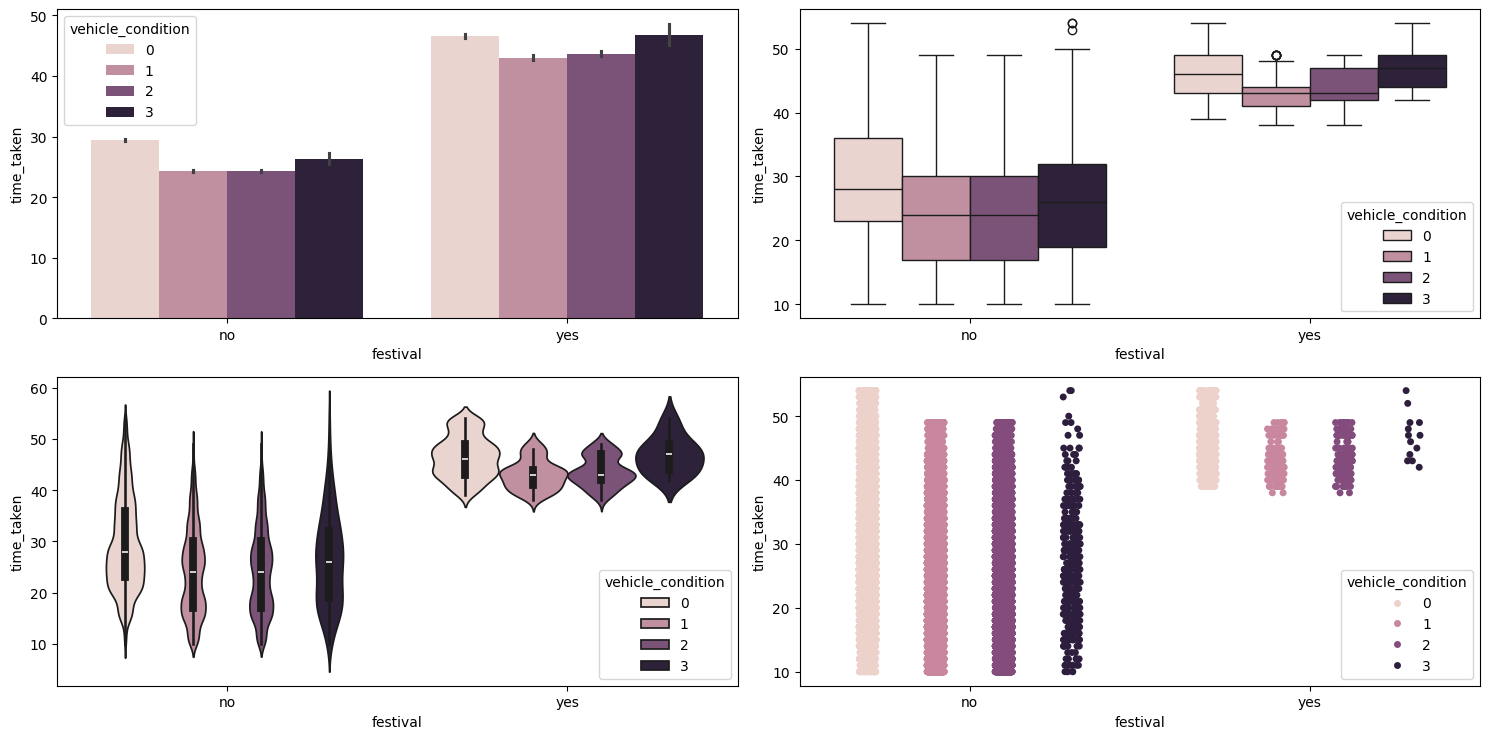

In [323]:
multivariate_analysis(df_final, "time_taken", "festival", "vehicle_condition")

# Multiple Deliveries



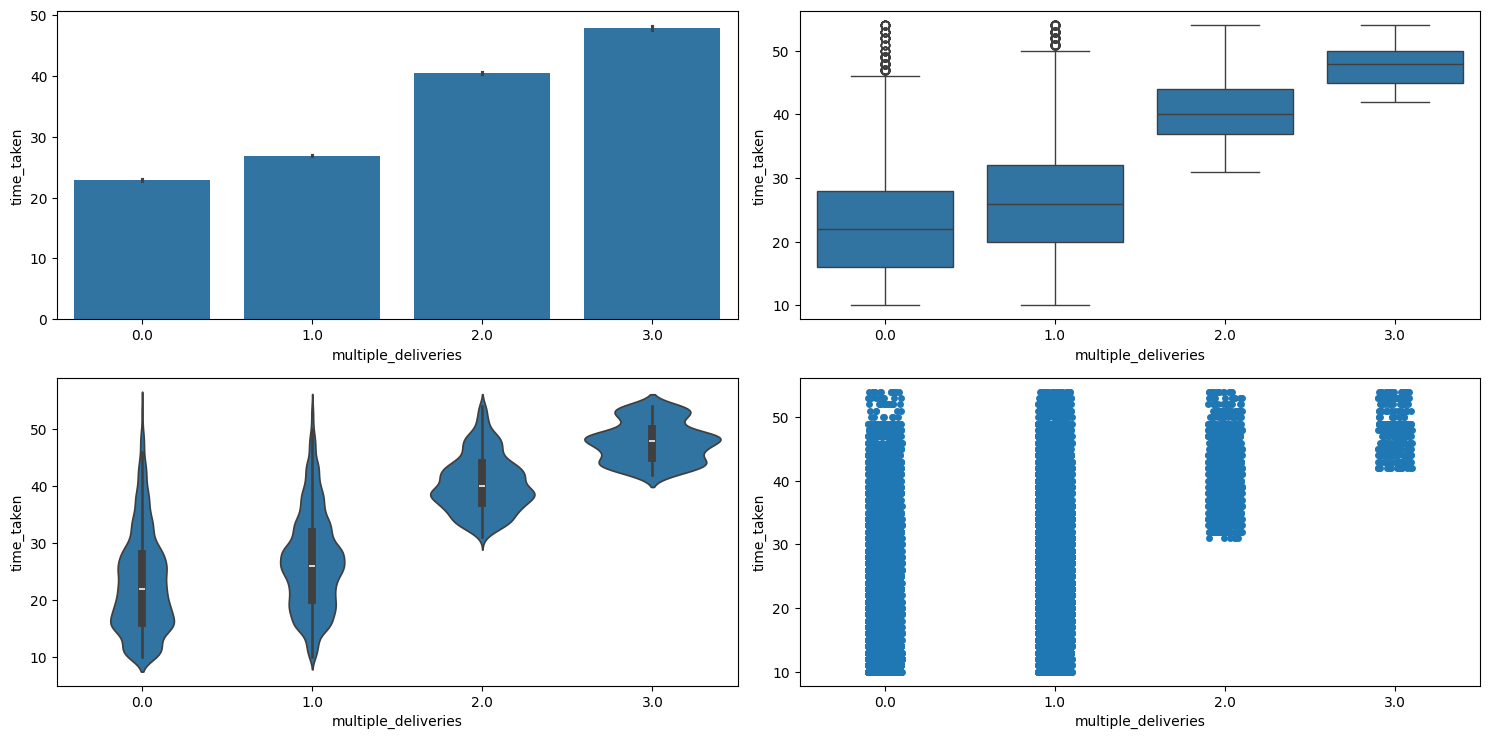

In [324]:
numerical_categorical_analysis(df_final, "multiple_deliveries", "time_taken")

In [325]:
# hypothesis test

anova_test(df_final, "time_taken", "multiple_deliveries")

ANOVA test results for time_taken and multiple_deliveries:
F-statistic: 188.4201
p-value: 0.0000
Reject the null hypothesis at alpha = 0.05


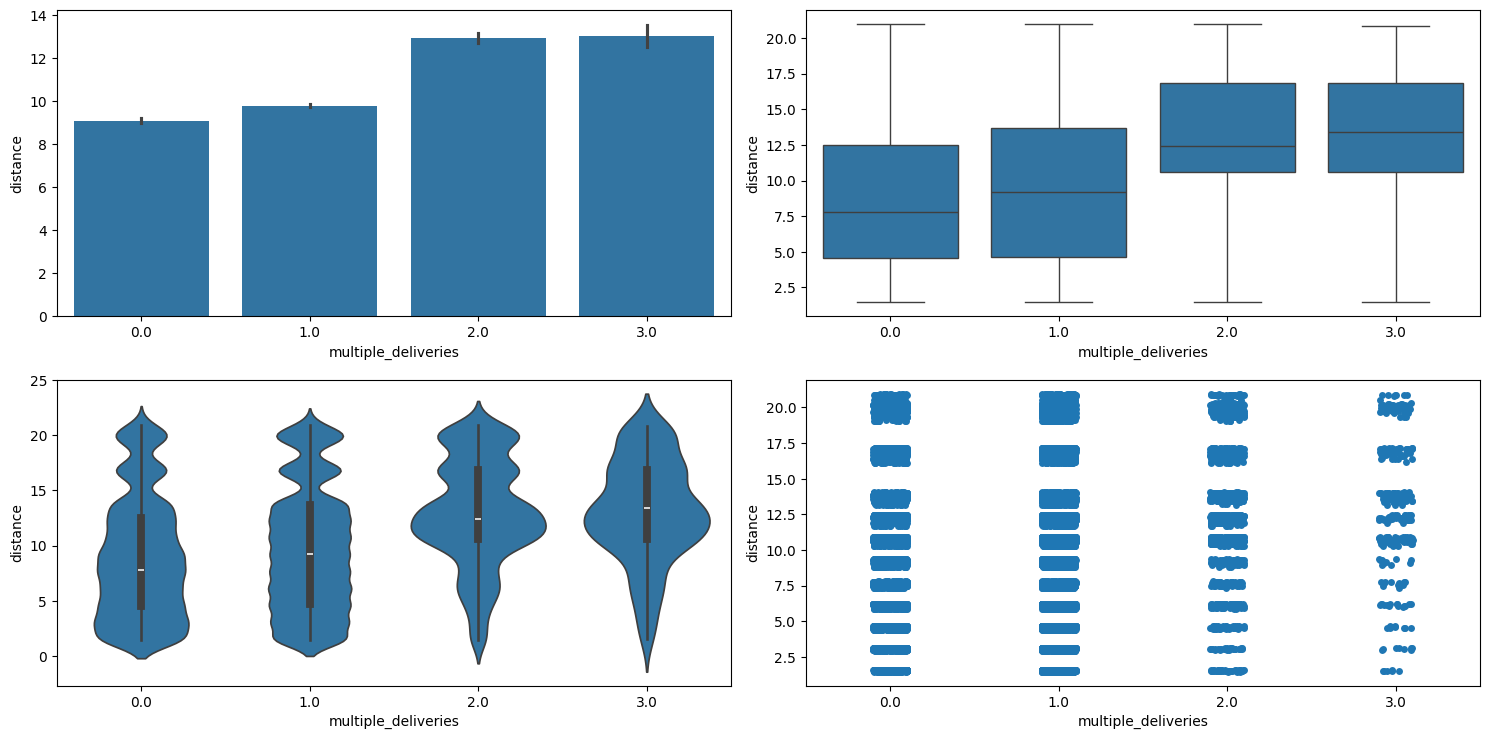

In [326]:
# do multiple deliveries are of longer distances

numerical_categorical_analysis(df_final, "multiple_deliveries", "distance")

## Weather

In [327]:
df_final['weather'].dtype

dtype('O')

,Count,Percentage
weather,,
fog,7654,17.02%
stormy,7586,16.87%
cloudy,7536,16.76%
sandstorms,7495,16.66%
windy,7422,16.5%
sunny,7284,16.19%


**************************************************
Number of unique values in weather: 6
**************************************************
Unique values in weather: ['sunny' 'stormy' 'sandstorms' 'cloudy' 'fog' 'windy' nan]
**************************************************


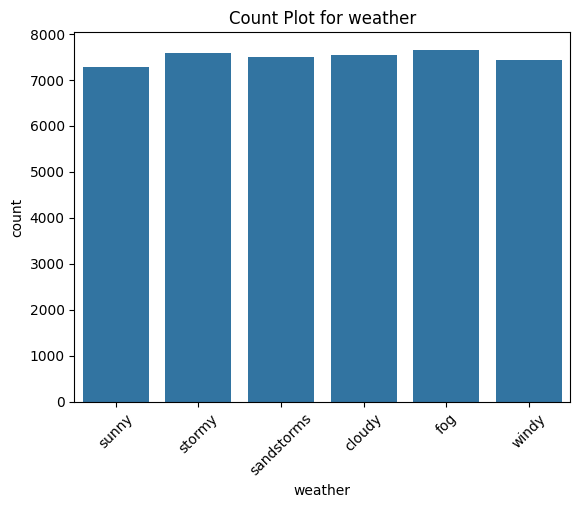

In [329]:
# categorical analysis on type of weather

categorical_analysis(df_final, "weather")

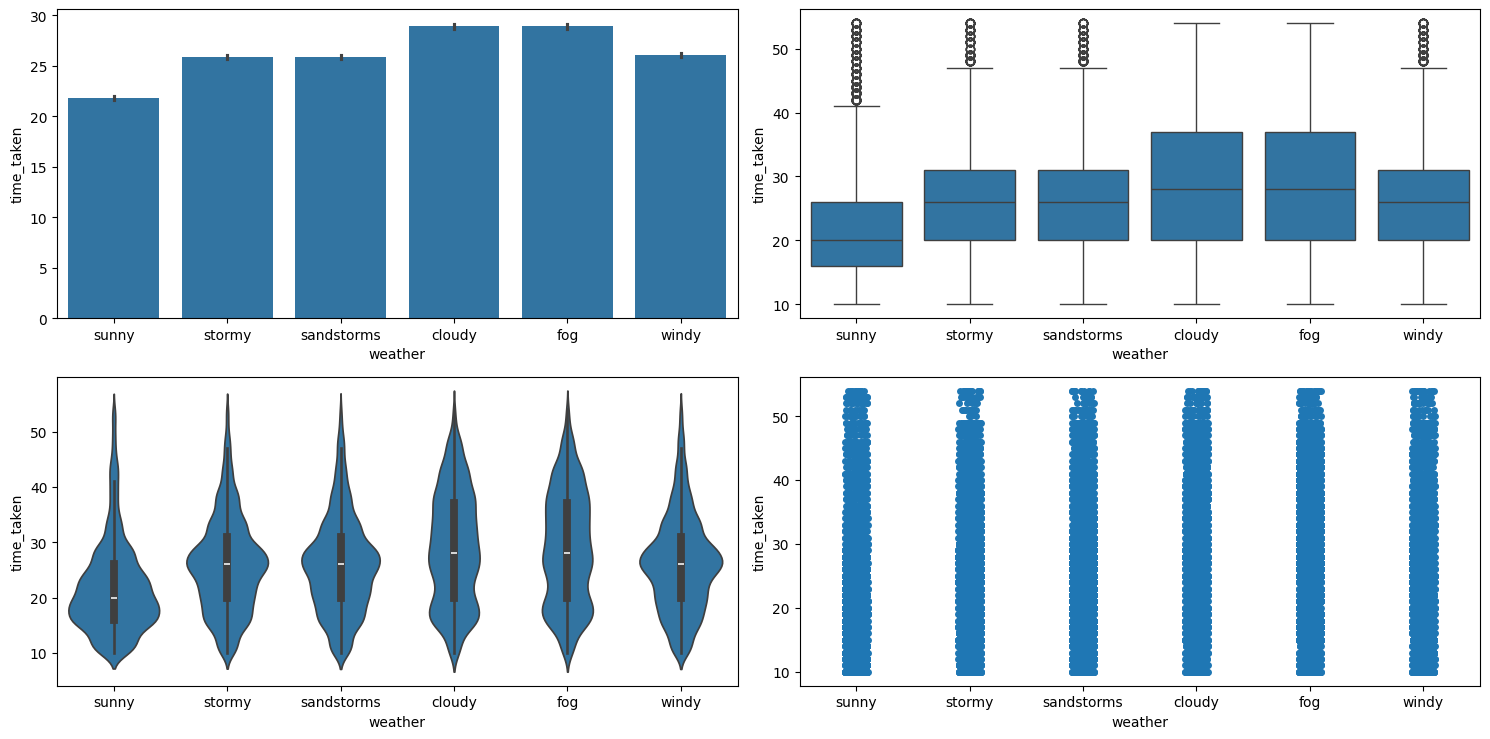

In [330]:
# does weather affect delivery times

numerical_categorical_analysis(df_final, "weather", "time_taken")

In [331]:
# hypothesis test
anova_test(df_final, "weather", "time_taken")

ANOVA test results for weather and time_taken:
F-statistic: 608.2196
p-value: 0.0000
Reject the null hypothesis at alpha = 0.05


In [333]:
# does the weather affects traffic

chi2_test(df_final, "weather", "traffic")

Chi-Squared test results for weather and traffic:
Chi2 statistic: 14.6130
Degrees of freedom: 15
Expected frequencies:
[[ 741.25139516 2369.18958579 2591.86659848 1833.69242057]
 [ 752.85803855 2406.28676879 2632.45049692 1862.40469573]
 [ 737.21857838 2356.29988661 2577.76541343 1823.71612157]
 [ 746.16946439 2384.90873113 2609.06316562 1845.85863886]
 [ 716.46432621 2289.96509327 2505.19590013 1772.37468039]
 [ 730.0381973  2333.34993441 2552.65842542 1805.95344287]]
p-value: 0.4796
Fail to reject the null hypothesis at alpha = 0.05


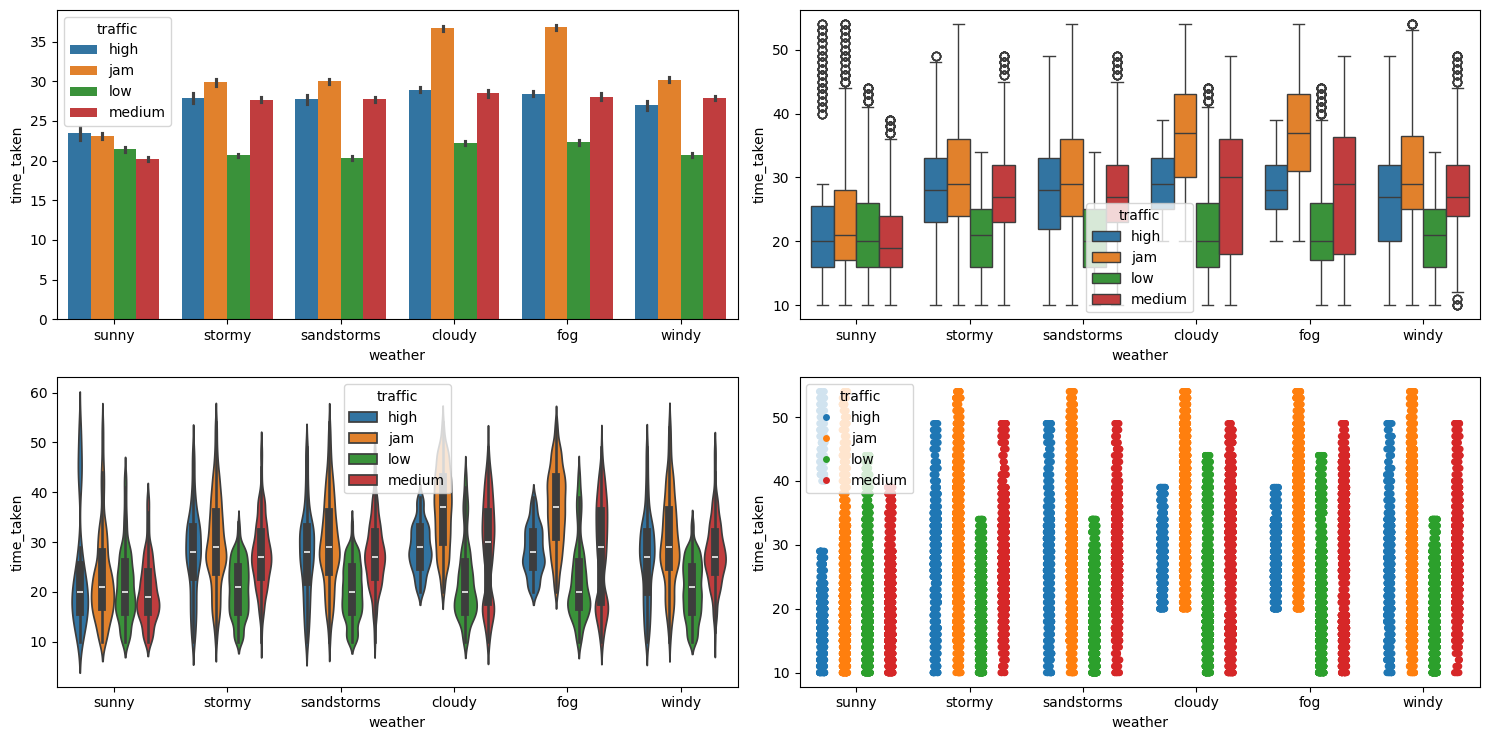

In [334]:
# delivery time based on weather and traffic
multivariate_analysis(df_final, "time_taken", "weather", "traffic")

**Seems like traffic along with other features combined acts as great discriminatory feature**

In [335]:
# pivot table
df_final.pivot_table(index="weather",columns="traffic",values="time_taken",aggfunc="mean")

traffic,high,jam,low,medium
weather,,,,
cloudy,28.940860,36.689655,22.208445,28.483134
fog,28.426546,36.806916,22.303427,28.044816
sandstorms,27.711840,30.018758,20.297049,27.738522
stormy,27.845839,29.850194,20.681734,27.680502
sunny,23.448980,23.082132,21.449293,20.195518
windy,26.972789,30.219056,20.665862,27.888769


## Vehicle - Condition and Type

,Count,Percentage
vehicle_condition,,
2,15034,33.04%
1,15030,33.03%
0,15009,32.99%
3,429,0.94%


**************************************************
Number of unique values in vehicle_condition: 4
**************************************************
Unique values in vehicle_condition: [2 0 1 3]
**************************************************


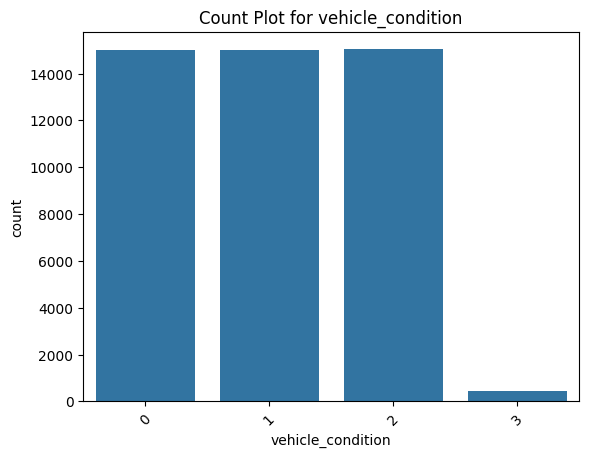

In [336]:
# categorical analysis on vehicle condition
categorical_analysis(df_final, "vehicle_condition")

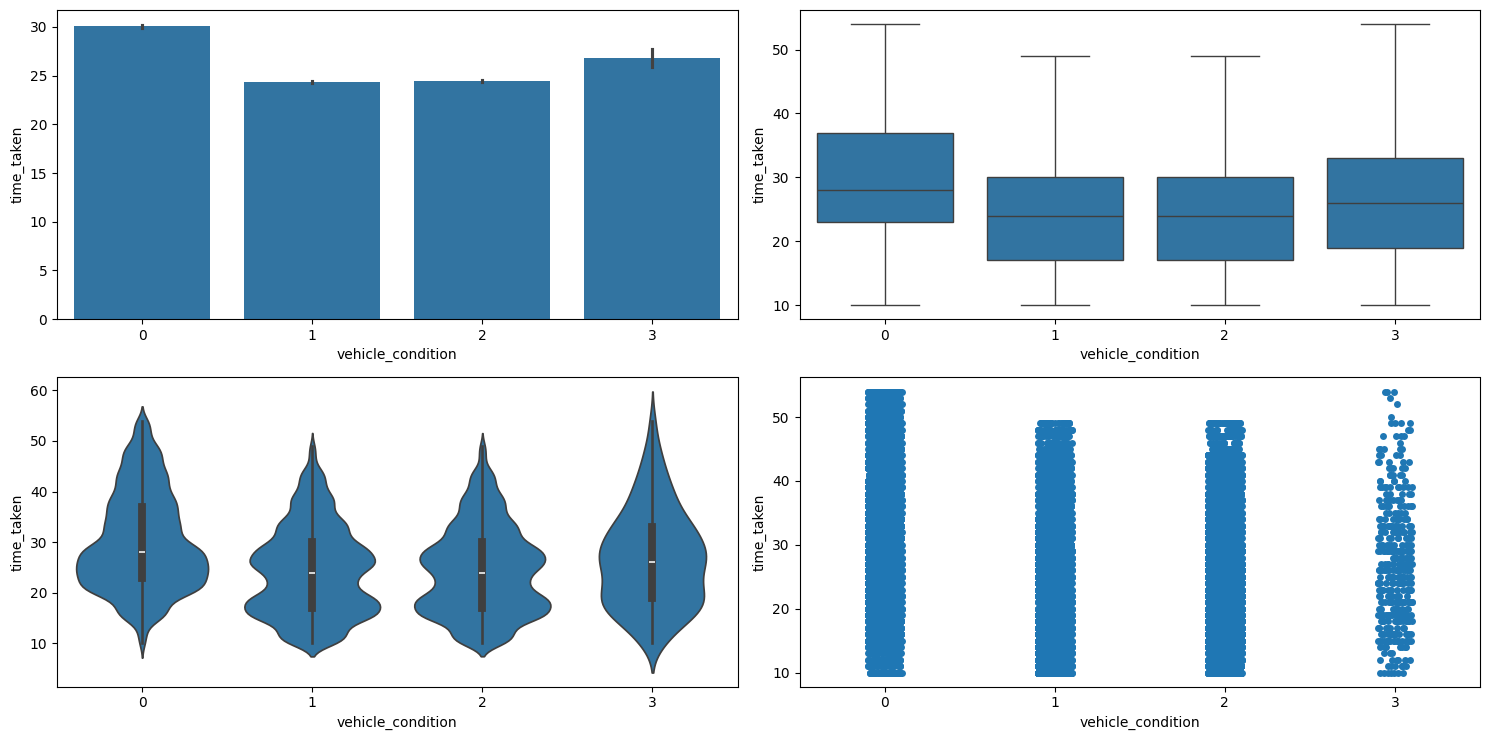

In [337]:
# does vehicle condition affect delivery times

numerical_categorical_analysis(df_final, "vehicle_condition", "time_taken")

In [338]:
# anova test

anova_test(df_final, "time_taken", "vehicle_condition")

ANOVA test results for time_taken and vehicle_condition:
F-statistic: 85.9972
p-value: 0.0000
Reject the null hypothesis at alpha = 0.05


,Count,Percentage
type_of_vehicle,,
motorcycle,26427,58.08%
scooter,15244,33.5%
electric_scooter,3778,8.3%
bicycle,53,0.12%


**************************************************
Number of unique values in type_of_vehicle: 4
**************************************************
Unique values in type_of_vehicle: ['motorcycle' 'scooter' 'electric_scooter' 'bicycle']
**************************************************


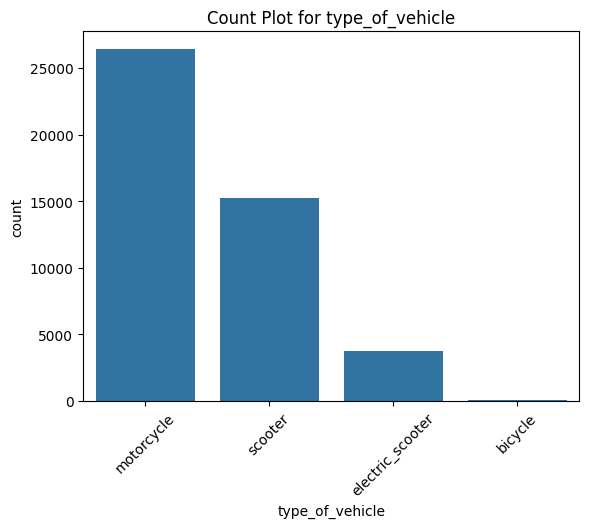

In [339]:
# analysis on vehicle type

categorical_analysis(df_final, "type_of_vehicle")

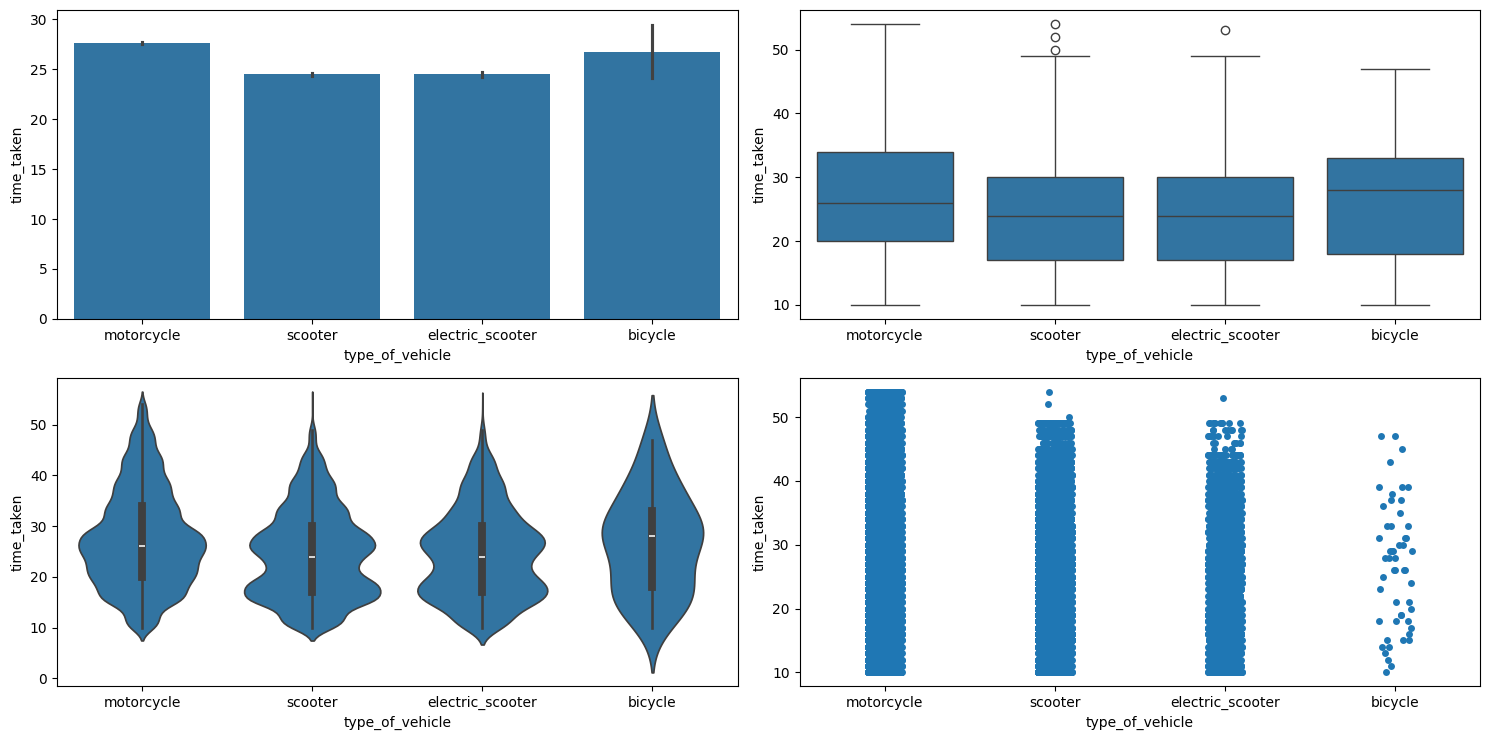

In [340]:
# does the type of vehicle affects delivery time

numerical_categorical_analysis(df_final, "type_of_vehicle", "time_taken")

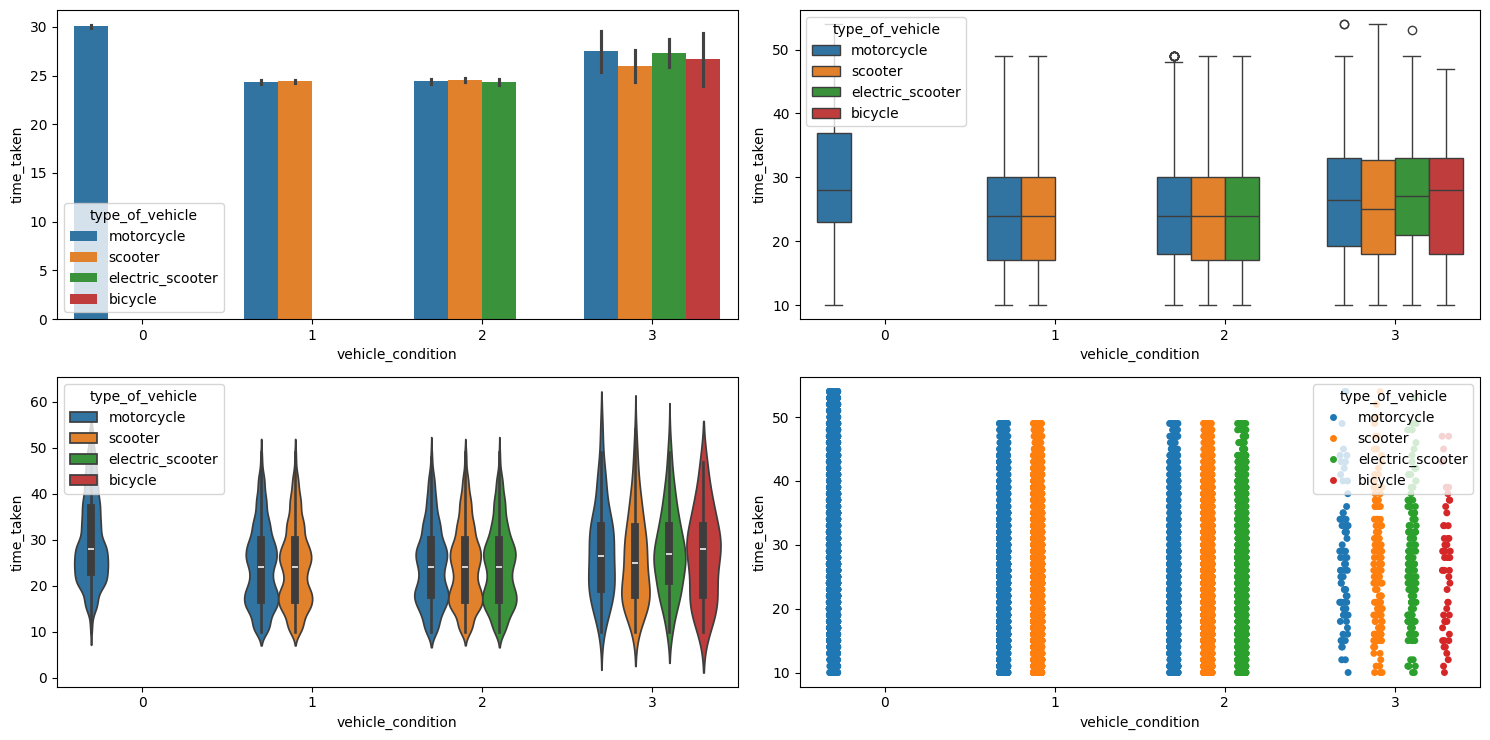

In [341]:
# vehicle condition and type

multivariate_analysis(df_final, "time_taken", "vehicle_condition", "type_of_vehicle")

In [343]:
# is their a relation between vehicle type and conditions

chi2_test(df_final, "type_of_vehicle", "vehicle_condition")

Chi-Squared test results for type_of_vehicle and vehicle_condition:
Chi2 statistic: 28159.4382
Degrees of freedom: 9
Expected frequencies:
[[1.74822425e+01 1.75067030e+01 1.75113621e+01 4.99692321e-01]
 [1.24618702e+03 1.24793064e+03 1.24826276e+03 3.56195772e+01]
 [8.71704195e+03 8.72923850e+03 8.73156165e+03 2.49157905e+02]
 [5.02828878e+03 5.03532416e+03 5.03666423e+03 1.43722825e+02]]
p-value: 0.0000
Reject the null hypothesis at alpha = 0.05


## Type of Order

In [345]:
# type of order dtype

df_final['type_of_order'].dtype

dtype('O')

,Count,Percentage
type_of_order,,
snack,11512,25.3%
meal,11435,25.13%
drinks,11294,24.82%
buffet,11261,24.75%


**************************************************
Number of unique values in type_of_order: 4
**************************************************
Unique values in type_of_order: ['snack' 'drinks' 'buffet' 'meal']
**************************************************


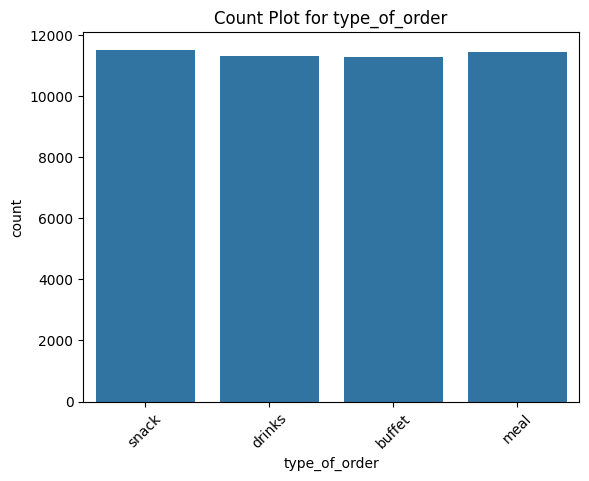

In [346]:
# analysis on type of order

categorical_analysis(df_final, "type_of_order")

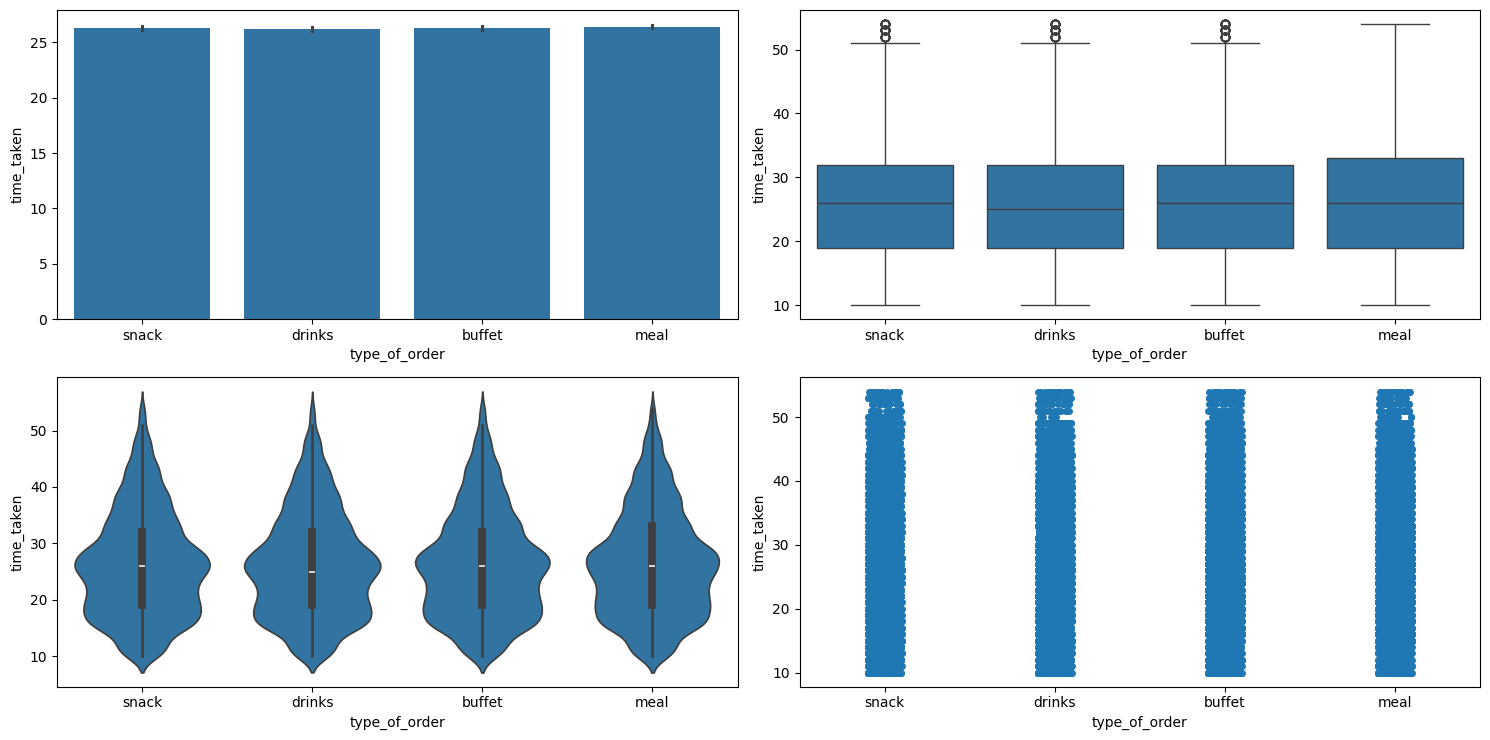

In [347]:
# does order type have have effect on delivery times

numerical_categorical_analysis(df_final, "type_of_order", "time_taken")

In [349]:
# hypothesis test

anova_test(df_final,  "type_of_order","time_taken")

ANOVA test results for type_of_order and time_taken:
F-statistic: 1.2099
p-value: 0.3043
Fail to reject the null hypothesis at alpha = 0.05


In [350]:
# contingency table

pd.crosstab(df_final["type_of_order"],df_final["is_weekend"])

is_weekend,0,1
type_of_order,,
buffet,8238,3023
drinks,8130,3164
meal,8290,3145
snack,8337,3175


In [351]:
# does type of order have an effect over pickup time

chi2_test(df_final,"pickup_time_minutes","type_of_order")

Chi-Squared test results for pickup_time_minutes and type_of_order:
Chi2 statistic: 5.4200
Degrees of freedom: 6
Expected frequencies:
[[3639.04445762 3652.78808536 3693.34854772 3717.81890931]
 [3600.92891341 3614.52858967 3654.6642196  3678.87827732]
 [3616.02662897 3629.68332497 3669.98723268 3694.30281337]]
p-value: 0.4912
Fail to reject the null hypothesis at alpha = 0.05


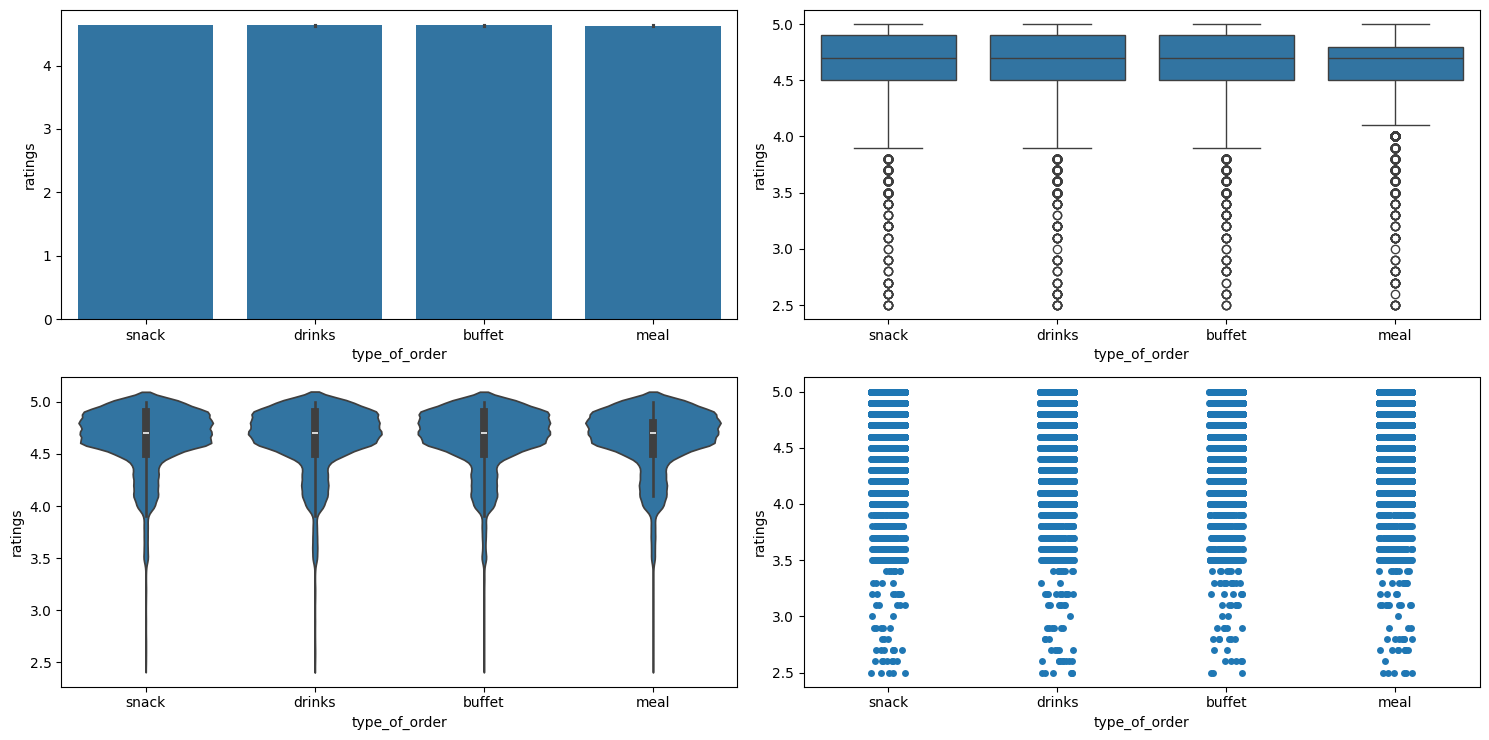

In [352]:
# does order type has an effect on ratings

numerical_categorical_analysis(df_final, "type_of_order", "ratings")

In [354]:
# is their a relationship between weekends and type of order

chi2_test(df_final, "is_weekend", "type_of_order")

Chi-Squared test results for is_weekend and type_of_order:
Chi2 statistic: 3.9600
Degrees of freedom: 3
Expected frequencies:
[[8165.72227594 8189.65166366 8291.89541119 8347.7306492 ]
 [3095.27772406 3104.34833634 3143.10458881 3164.2693508 ]]
p-value: 0.2658
Fail to reject the null hypothesis at alpha = 0.05


In [356]:
# is their a relationship between festivals and type of order

chi2_test(df_final, "festival", "type_of_order")

Chi-Squared test results for festival and type_of_order:
Chi2 statistic: 1.8002
Degrees of freedom: 3
Expected frequencies:
[[10980.80045942 11009.22781287 11155.28559438 11234.68613332]
 [  221.19954058   221.77218713   224.71440562   226.31386668]]
p-value: 0.6149
Fail to reject the null hypothesis at alpha = 0.05


,Count,Percentage
city_name,,
JAP,3439,7.56%
RANCHI,3222,7.08%
BANG,3184,7.0%
SUR,3182,6.99%
HYD,3177,6.98%
MUM,3168,6.96%
MYS,3164,6.95%
COIMB,3162,6.95%
VAD,3159,6.94%


**************************************************
Number of unique values in city_name: 22
**************************************************
Unique values in city_name: ['INDO' 'BANG' 'COIMB' 'CHEN' 'HYD' 'RANCHI' 'MYS' 'DEH' 'KOC' 'PUNE'
 'LUDH' 'KNP' 'MUM' 'KOL' 'JAP' 'SUR' 'GOA' 'AURG' 'AGR' 'VAD' 'ALH' 'BHP']
**************************************************


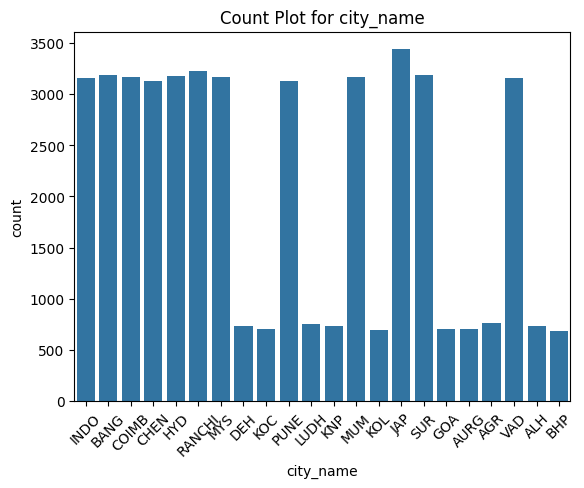

In [357]:
# categorical analysis on city name

categorical_analysis(df_final, "city_name")

,Count,Percentage
city_type,,
metropolitian,34029,76.81%
urban,10111,22.82%
semi-urban,164,0.37%


**************************************************
Number of unique values in city_type: 3
**************************************************
Unique values in city_type: ['urban' 'metropolitian' 'semi-urban' nan]
**************************************************


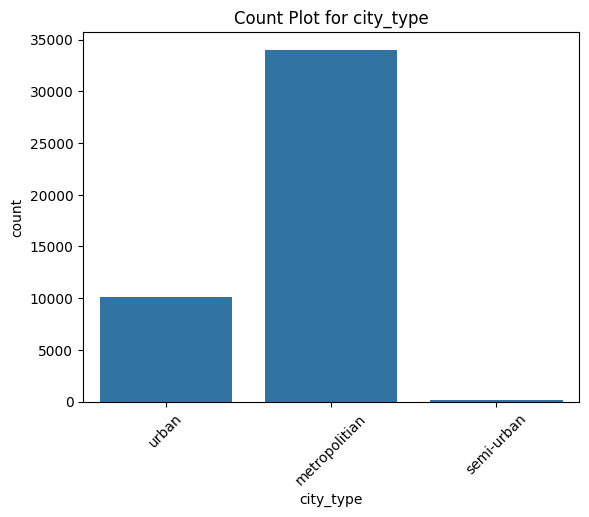

In [358]:
# categorical analysis on city type

categorical_analysis(df_final, "city_type")

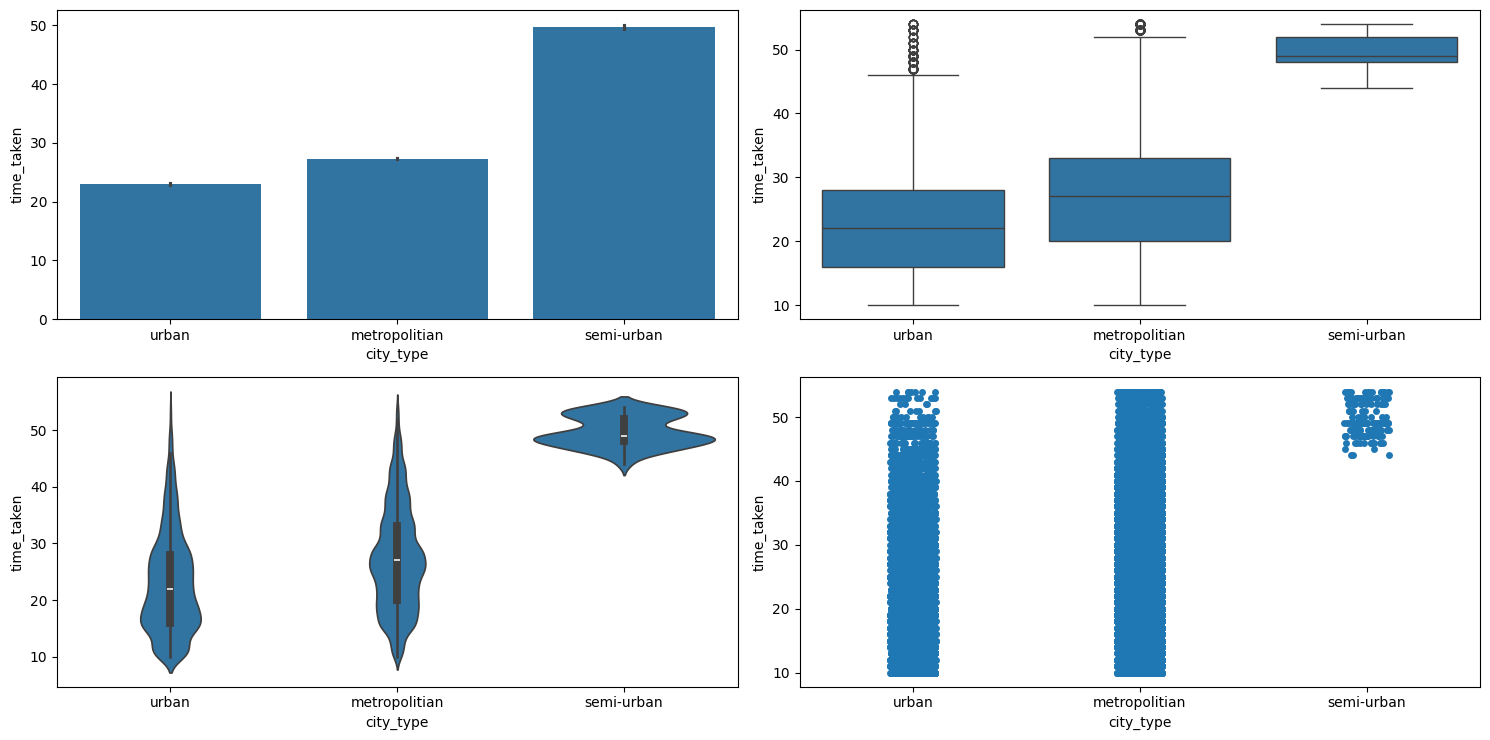

In [359]:
# does city types affect delivery times

numerical_categorical_analysis(df_final, "city_type", "time_taken")

In [361]:
# hypothesis test

anova_test(df_final, "city_type","time_taken")

ANOVA test results for city_type and time_taken:
F-statistic: 1423.3223
p-value: 0.0000
Reject the null hypothesis at alpha = 0.05


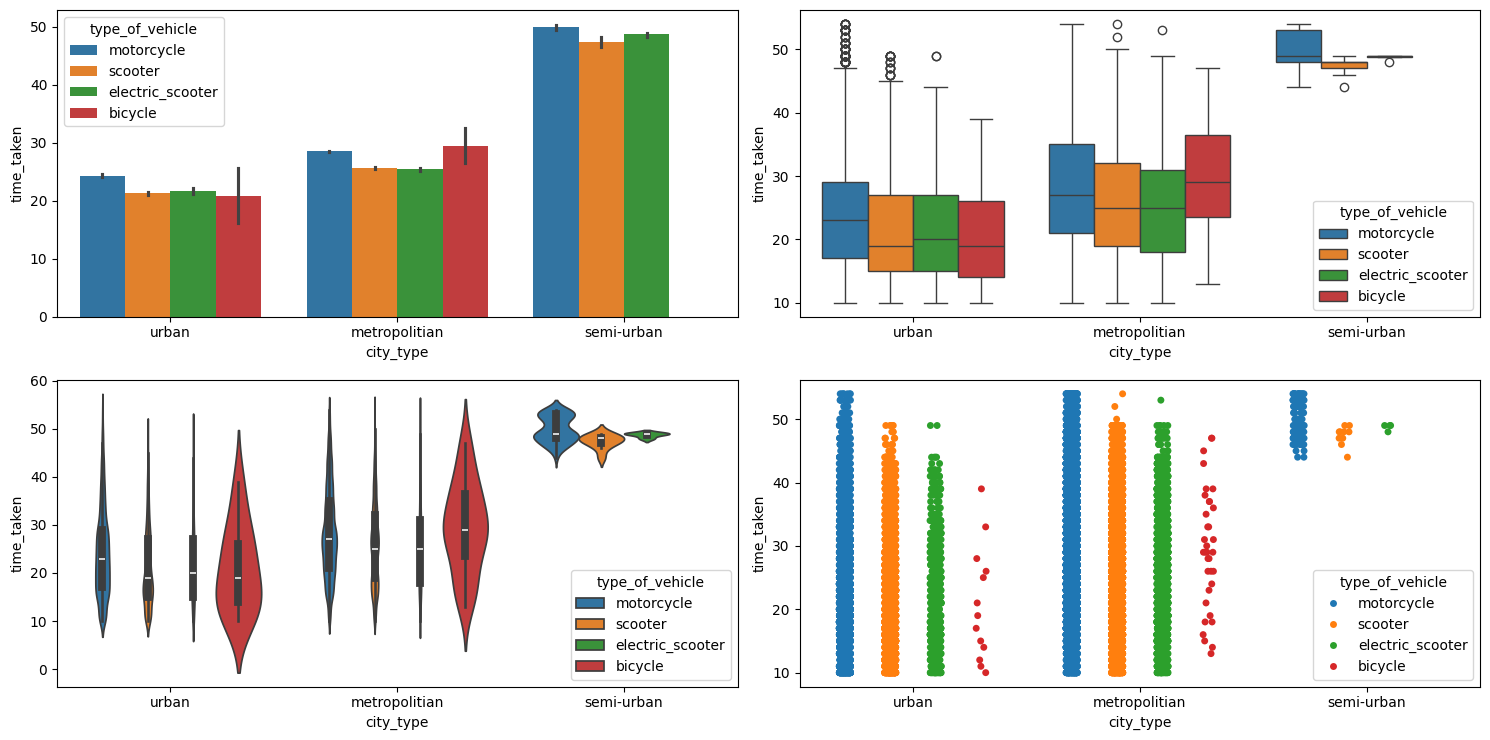

In [362]:
# city type, type of vehicle and delivery time analysis

multivariate_analysis(df_final, "time_taken", "city_type", "type_of_vehicle")

## Distance

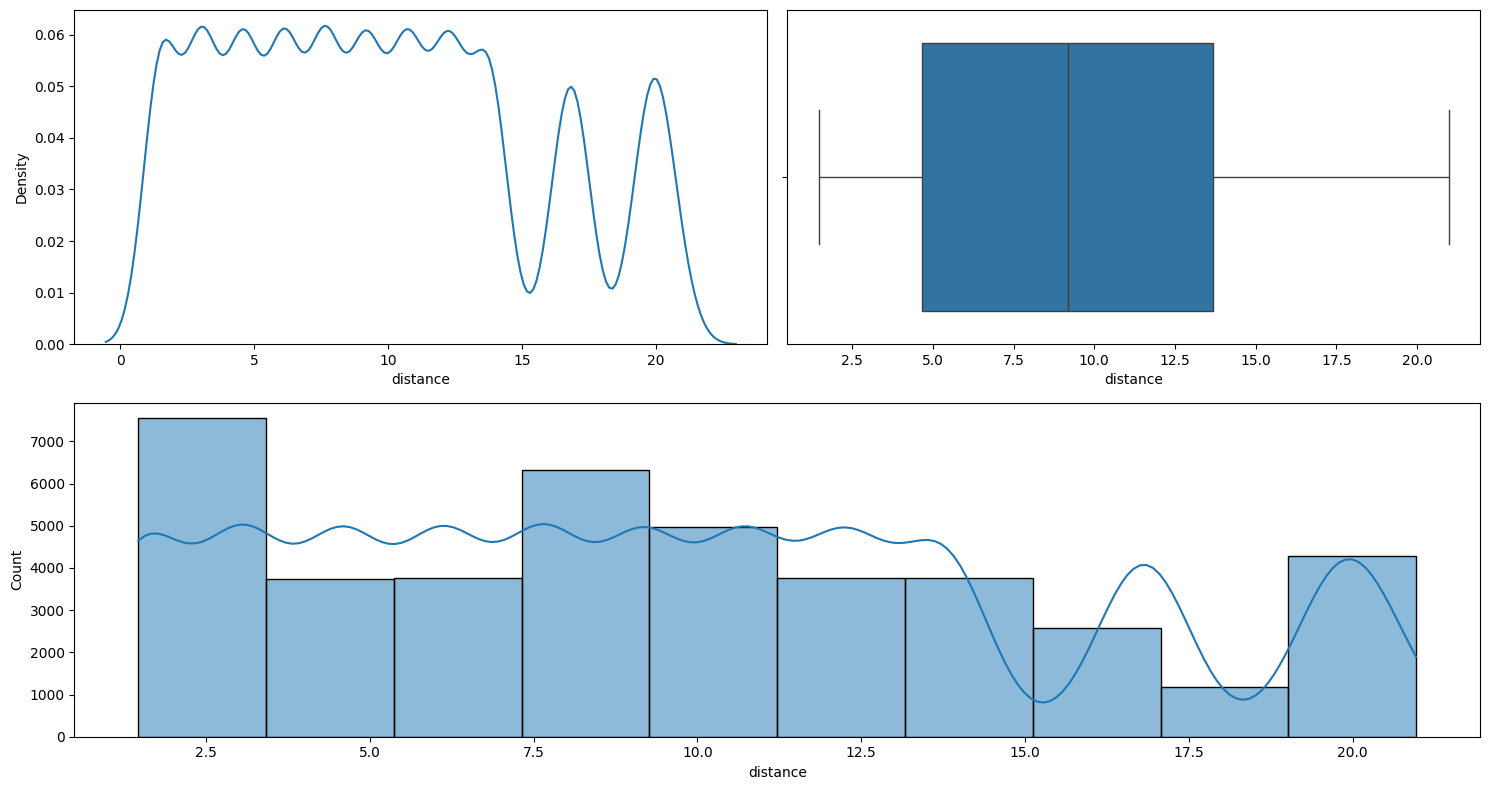

In [363]:
# numerical analysis of distance

numerical_analysis(df_final, "distance",bins=10)

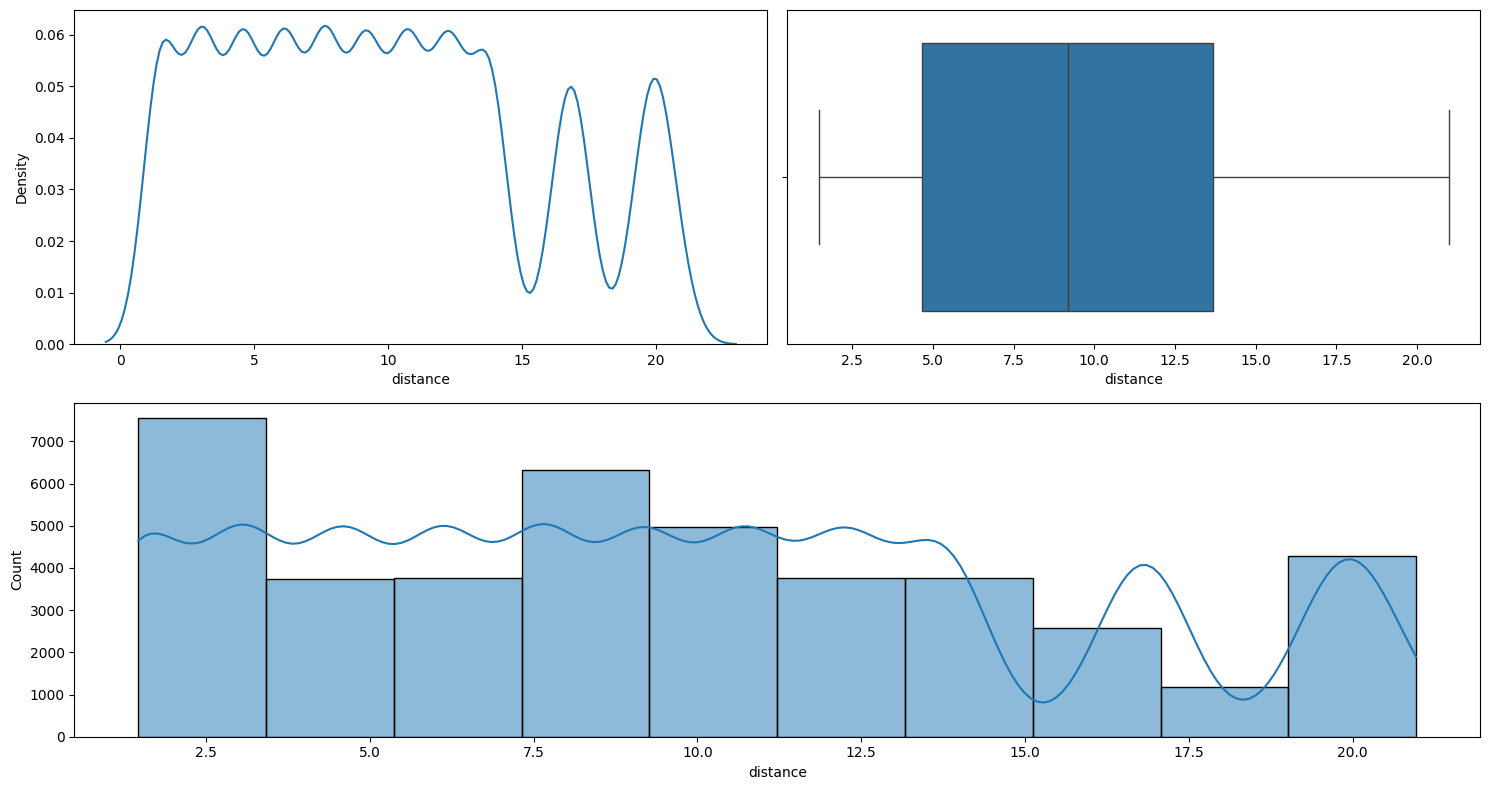

In [364]:
# numerical analysis of distance

numerical_analysis(df_final, "distance",bins=10)

In [365]:
# corr

df_final[["distance","time_taken"]].corr()

,distance,time_taken
distance,1.000000,0.320705
time_taken,0.320705,1.000000


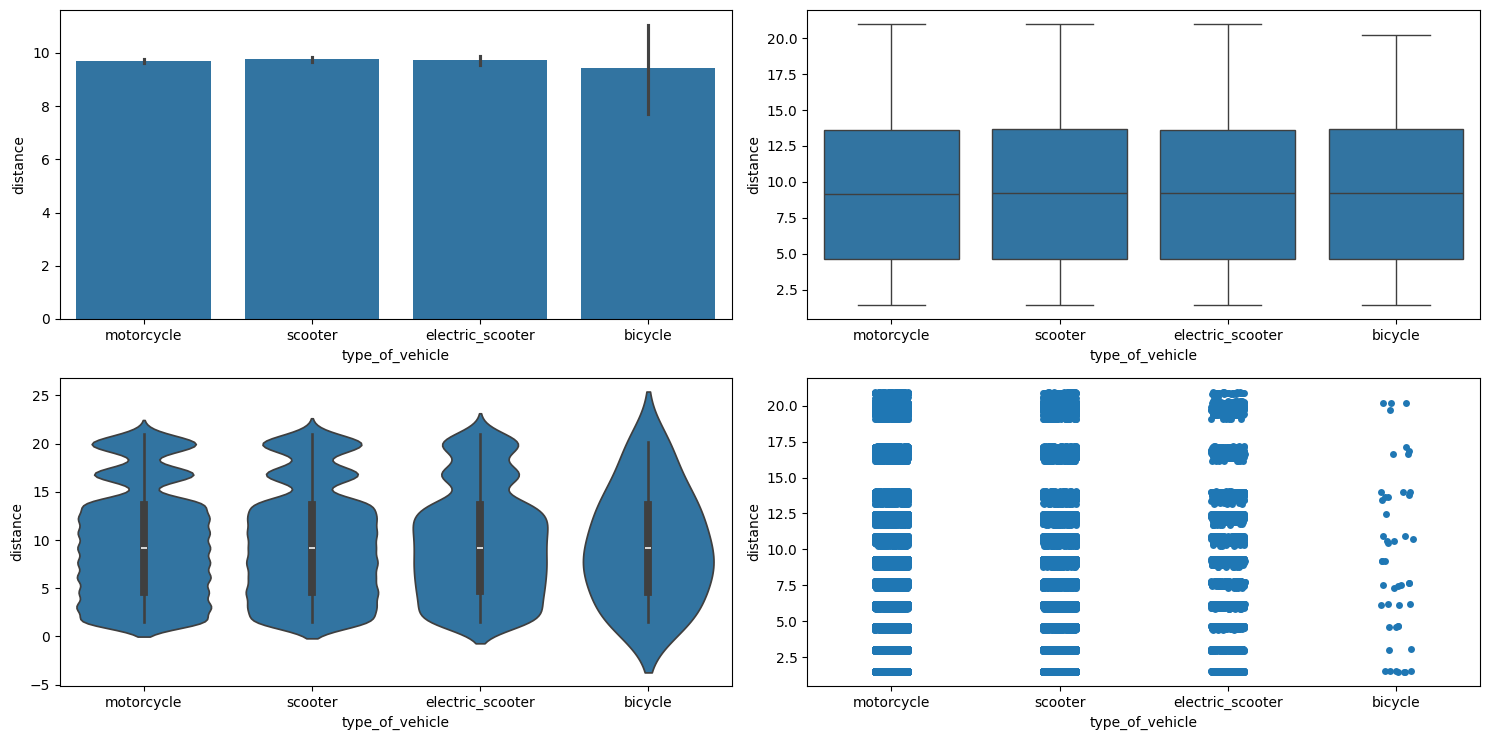

In [366]:
# vehicle type and distance analysis

numerical_categorical_analysis(df_final, "type_of_vehicle", "distance")

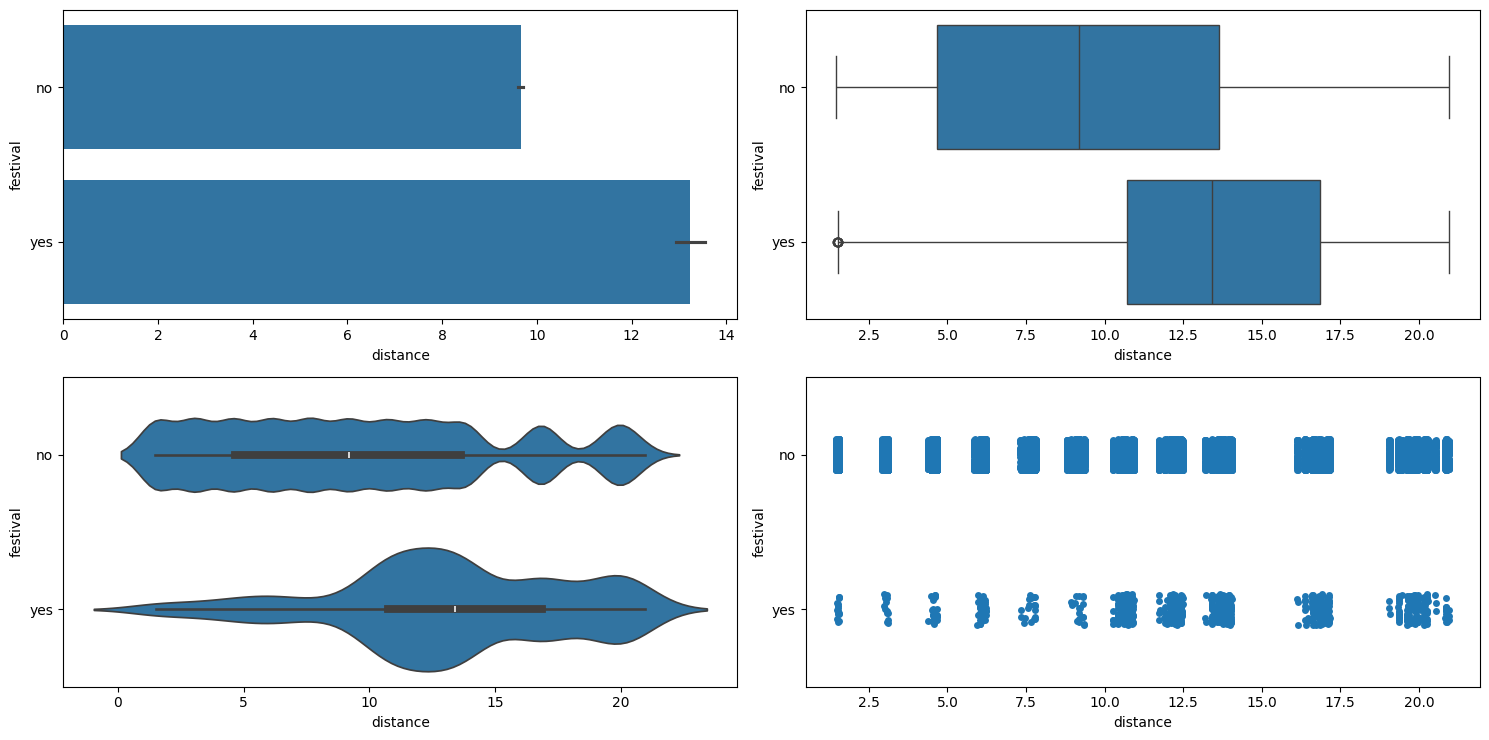

In [367]:
# do riders cover more distances during festivals

numerical_categorical_analysis(df_final, "distance", "festival")

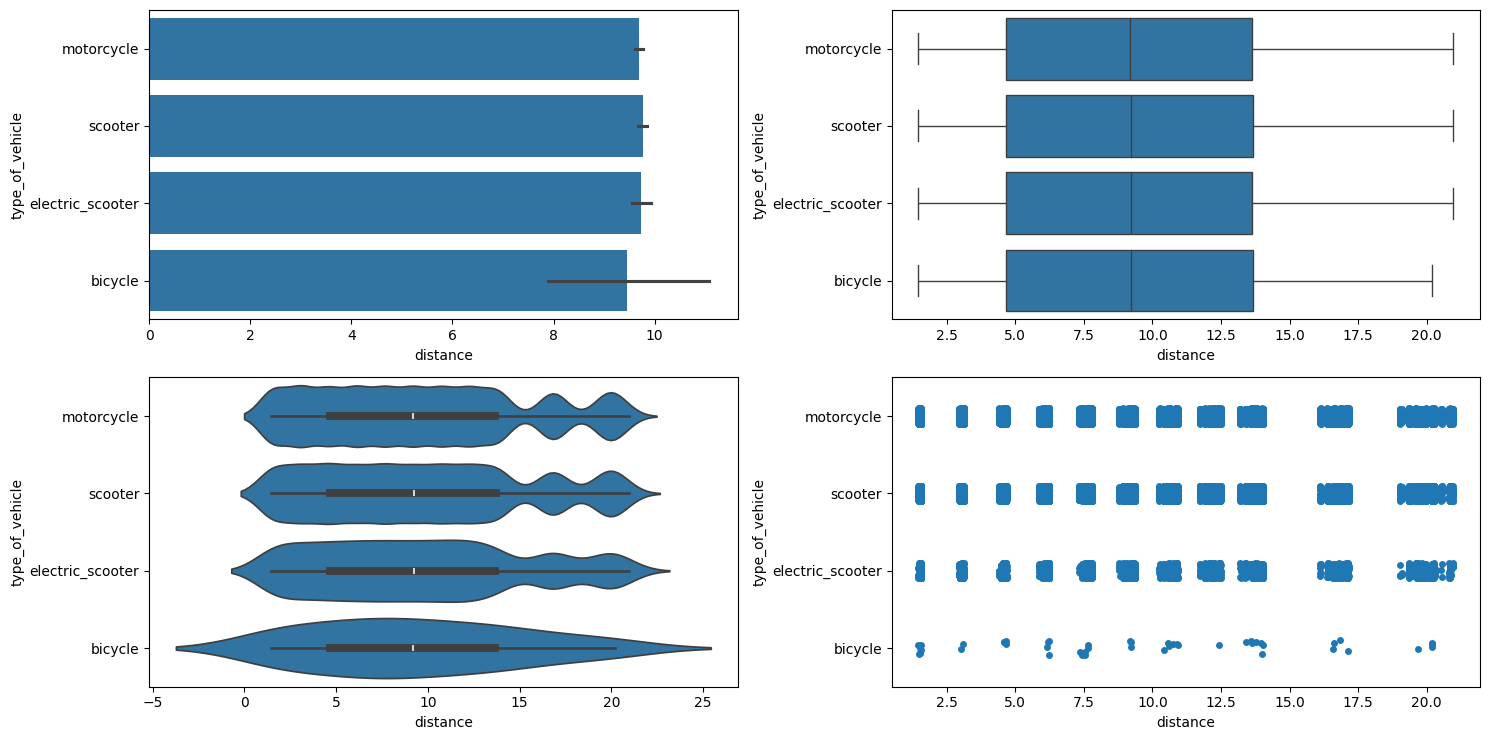

In [368]:
# distance and type of vehicle

numerical_categorical_analysis(df_final, "distance", "type_of_vehicle")

In [370]:
anova_test(df_final, "type_of_vehicle","distance")

ANOVA test results for type_of_vehicle and distance:
F-statistic: 0.5599
p-value: 0.6414
Fail to reject the null hypothesis at alpha = 0.05
